In [1]:
# !pip freeze > requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score)
from sklearn.feature_selection import SelectKBest, f_classif
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Maternal Health Risk Data Set.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1014, 7)

First few rows:
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk

Data types:
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

Summary statistics:
               Age   SystolicBP  DiastolicBP           BS     BodyTemp  \
count  1014.000000  1014.000000  1014.000000  1014.000000  1014.000000   
mean     29.871795   113.198225    76.460552     8.725986    98.665089   
std      13.474386    18.403913    13.885796     3.293532     1.371384   
min      10.000000    70.000000  

In [3]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


### Q1

<b>Comprehensive Data Quality Assessment for Clinical Plausibility</b><br>
This code block performs a rigorous data quality audit by systematically scanning the maternal health dataset for unusual or clinically implausible values, beginning with the definition of medically reasonable ranges for each clinical variable based on established obstetric knowledge—such as maternal age between 10–80 years, systolic blood pressure 70–180 mmHg, diastolic blood pressure 40–110 mmHg, blood sugar 4–20 mmol/L, body temperature 97–103, and heart rate 50–110 bpm. For each variable, it counts and displays any values falling outside these ranges, showing a preview of the unique offending values to help identify potential data entry errors, measurement anomalies, or rare but valid clinical outliers. The output reveals that most variables pass this sanity check, with only heart rate showing 2 records with an implausible value of 7 bpm—likely a data entry error requiring correction or removal. The code then performs two additional integrity checks: detecting duplicate records (finding 562 exact duplicates, suggesting possible data collection redundancies that should be addressed to avoid over-representation) and verifying physiological consistency by checking for impossible combinations such as diastolic blood pressure exceeding systolic blood pressure (finding none). Together, these validation steps provide a critical foundation for reliable analysis by flagging suspect data points, quantifying data quality issues, and informing preprocessing decisions—such as removing duplicates and correcting or dropping the anomalous heart rate values—before proceeding with further statistical modeling or machine learning.



In [5]:
# Identify unusual or implausible values
print("\n" + "=" * 60)
print("UNUSUAL OR IMPLAUSIBLE VALUES")
print("=" * 60)

# Define normal ranges based on clinical knowledge
ranges = {
    'Age': (10, 80),           # reasonable age range for pregnant women
    'SystolicBP': (70, 180),   # normal systolic range
    'DiastolicBP': (40, 110),  # normal diastolic range
    'BS': (4, 20),             # blood sugar (could be slightly higher in pregnancy)
    'BodyTemp': (97, 103),     # body temperature in Fahrenheit
    'HeartRate': (50, 110)     # heart rate range
}

unusual_values = {}
for var, (low, high) in ranges.items():
    outside = df[(df[var] < low) | (df[var] > high)]
    if len(outside) > 0:
        unusual_values[var] = outside[var].values
        print(f"\n{var}: {len(outside)} values outside normal range ({low}-{high})")
        print(f"  Values: {sorted(outside[var].unique())[:10]}...")
    else:
        print(f"\n{var}: All values within normal range ({low}-{high})")

# Check for duplicate records
duplicates = df.duplicated()
print(f"\nDuplicate records: {duplicates.sum()}")

# Check for impossible combinations (e.g., diastolic > systolic)
invalid_bp = df[df['DiastolicBP'] > df['SystolicBP']]
print(f"Records with DiastolicBP > SystolicBP: {len(invalid_bp)}")
if len(invalid_bp) > 0:
    print(invalid_bp[['SystolicBP', 'DiastolicBP']].head())


UNUSUAL OR IMPLAUSIBLE VALUES

Age: All values within normal range (10-80)

SystolicBP: All values within normal range (70-180)

DiastolicBP: All values within normal range (40-110)

BS: All values within normal range (4-20)

BodyTemp: All values within normal range (97-103)

HeartRate: 2 values outside normal range (50-110)
  Values: [np.int64(7)]...

Duplicate records: 562
Records with DiastolicBP > SystolicBP: 0


In [6]:
df.drop_duplicates(inplace=True)
df = df[df['HeartRate'] != 7]
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
673,12,100,50,6.4,98.0,70,mid risk
674,15,100,60,6.0,98.0,80,low risk
703,15,100,49,7.6,98.0,77,low risk
704,12,100,50,6.0,98.0,70,mid risk


This code block provides a foundational descriptive analysis of the maternal health dataset by first calculating and displaying the total sample size (451 records) and then generating a detailed breakdown of risk level distributions across the three categories: low risk, mid risk, and high risk. It creates a frequency table showing both the absolute counts and percentages for each risk group, revealing that low-risk cases constitute the majority at approximately 51.7% (233 records), followed by high risk at 24.8% (112 records) and mid risk at 23.5% (106 records), indicating a moderately imbalanced dataset with nearly twice as many low-risk cases as either of the other two categories. To enhance interpretability, the code generates a dual visualization comprising a bar plot with distinct color coding (green for low, yellow for mid, red for high) and annotated count labels above each bar, alongside a pie chart that displays the proportional breakdown with percentage labels, both arranged side-by-side for comparative viewing. The visualization is saved as a high-resolution PNG file in a 'figures' directory for inclusion in reports or presentations, providing a clear and professional summary of the risk group distribution that establishes the context for subsequent analyses and helps identify potential class imbalance issues that may need to be addressed through techniques like resampling or weighted modeling in later stages of the workflow.

Q1 - MATERNAL RISK POPULATION DESCRIPTION

Total sample size: 451 records

--- Risk Level Distribution ---
           Count  Percentage
RiskLevel                   
low risk     233   51.662971
high risk    112   24.833703
mid risk     106   23.503326


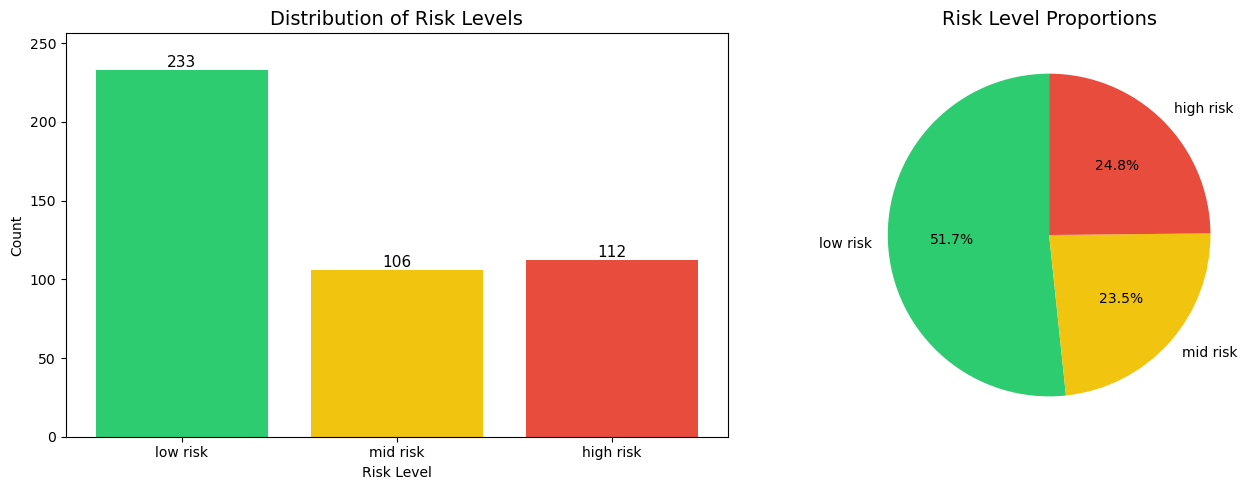

In [7]:
# Q1 - Describe the sample and distribution of risk groups

print("=" * 60)
print("Q1 - MATERNAL RISK POPULATION DESCRIPTION")
print("=" * 60)

print(f"\nTotal sample size: {len(df)} records")

print("\n--- Risk Level Distribution ---")
risk_counts = df['RiskLevel'].value_counts()
risk_pct = df['RiskLevel'].value_counts(normalize=True) * 100
risk_df = pd.DataFrame({'Count': risk_counts, 'Percentage': risk_pct})
print(risk_df)

# Create visualization for risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
risk_order = ['low risk', 'mid risk', 'high risk']
ax1 = axes[0]
risk_counts_sorted = risk_counts.reindex(risk_order)
ax1.bar(risk_counts_sorted.index, risk_counts_sorted.values, color=colors)
ax1.set_title('Distribution of Risk Levels', fontsize=14)
ax1.set_xlabel('Risk Level')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(risk_counts) * 1.1)
for i, v in enumerate(risk_counts_sorted.values):
    ax1.text(i, v + 2, str(v), ha='center', fontsize=11)

# Pie chart
ax2 = axes[1]
ax2.pie(risk_counts_sorted.values, labels=risk_counts_sorted.index, 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Risk Level Proportions', fontsize=14)

plt.tight_layout()
plt.savefig('../figures/risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

This code block provides a comprehensive statistical summary of the six key clinical variables in the maternal health dataset—Age, SystolicBP, DiastolicBP, BS (Blood Sugar), BodyTemp, and HeartRate—by calculating and displaying eight essential descriptive metrics for each variable: mean, median, standard deviation, minimum, maximum, and the first and third quartiles (Q1 and Q3). The output reveals important characteristics of the sample, such as a mean maternal age of 29.22 years with a wide range from 10 to 70 years (indicating a diverse population including both very young and older mothers), systolic blood pressure averaging 110.53 mmHg with values spanning 70–160 mmHg, and diastolic blood pressure ranging from 49–100 mmHg with a mean of 75.42 mmHg. Blood sugar levels show a mean of 8.35 with a relatively narrow interquartile range (6.90–7.90), suggesting most values cluster near the lower end despite a maximum of 19.0, while body temperature is remarkably consistent with a mean of 98.69°F and a median of 98.0°F, though the Q1 and Q3 both being 98.0°F indicates that at least 50% of observations share this exact value, potentially reflecting measurement rounding or a highly homogeneous population. Heart rate averages 74.10 bpm with values ranging from 60–90 bpm, falling within normal physiological ranges. Together, these summary statistics provide a quantitative foundation for understanding the central tendencies, variability, and distributional shape of each clinical measurement, enabling clinicians and data scientists to quickly assess data quality, identify potential outliers, and gain initial insights into the physiological profile of the maternal population before proceeding with more advanced analyses.

In [8]:
# Q1 - Summarize main clinical variables
print("\n" + "=" * 60)
print("SUMMARY OF MAIN CLINICAL VARIABLES")
print("=" * 60)

clinical_vars = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
for var in clinical_vars:
    print(f"\n--- {var} ---")
    print(f"Mean: {df[var].mean():.2f}")
    print(f"Median: {df[var].median():.2f}")
    print(f"Std: {df[var].std():.2f}")
    print(f"Min: {df[var].min():.2f}")
    print(f"Max: {df[var].max():.2f}")
    print(f"Q1: {df[var].quantile(0.25):.2f}")
    print(f"Q3: {df[var].quantile(0.75):.2f}")


SUMMARY OF MAIN CLINICAL VARIABLES

--- Age ---
Mean: 29.22
Median: 25.00
Std: 13.77
Min: 10.00
Max: 70.00
Q1: 19.00
Q3: 35.00

--- SystolicBP ---
Mean: 110.53
Median: 120.00
Std: 17.89
Min: 70.00
Max: 160.00
Q1: 90.00
Q3: 120.00

--- DiastolicBP ---
Mean: 75.42
Median: 80.00
Std: 13.77
Min: 49.00
Max: 100.00
Q1: 65.00
Q3: 87.00

--- BS ---
Mean: 8.35
Median: 7.50
Std: 2.83
Min: 6.00
Max: 19.00
Q1: 6.90
Q3: 7.90

--- BodyTemp ---
Mean: 98.69
Median: 98.00
Std: 1.41
Min: 98.00
Max: 103.00
Q1: 98.00
Q3: 98.00

--- HeartRate ---
Mean: 74.10
Median: 76.00
Std: 7.53
Min: 60.00
Max: 90.00
Q1: 70.00
Q3: 80.00


### Q2

This code block performs a comparative analysis of all six clinical variables across the three maternal risk levels (low, mid, and high risk) by first calculating and displaying key summary statistics—mean, median, standard deviation, minimum, and maximum—for each variable stratified by risk group, allowing for direct visual comparison of how physiological measurements differ between risk categories. The output reveals clinically meaningful patterns, such as high-risk mothers having the highest mean age (33.73 years), systolic blood pressure (119.49 mmHg), diastolic blood pressure (81.54 mmHg), blood sugar (11.17), body temperature (99.23°F), and heart rate (76.48 bpm), with all variables showing progressively increasing values from low-risk to high-risk groups, suggesting a cumulative physiological burden associated with higher risk status. Notably, blood sugar (BS) demonstrates the most dramatic separation between groups, with high-risk cases averaging 11.17 compared to 7.20 in low-risk and 7.89 in mid-risk, indicating that glucose metabolism may be the most powerful differentiator of risk. To statistically validate these observed differences, the code performs a one-way Analysis of Variance (ANOVA) test for each clinical variable, comparing the means across all three risk groups simultaneously, and the results show that all six variables have highly significant p-values (all < 0.001), with blood sugar yielding the largest F-statistic (114.15), confirming that the differences between risk groups are not due to random chance and that all clinical measurements contribute meaningfully to distinguishing maternal risk levels, though the magnitude of these differences varies substantially across variables as evidenced by the F-statistic range.

In [9]:
# Q2 - Compare measurements across risk groups
print("\n" + "=" * 60)
print("Q2 - MEASUREMENTS ACROSS RISK GROUPS")
print("=" * 60)

# Group by RiskLevel and calculate statistics
risk_groups = df.groupby('RiskLevel')
risk_stats = {}

for var in clinical_vars:
    stats_df = risk_groups[var].agg(['mean', 'median', 'std', 'min', 'max'])
    stats_df.columns = ['Mean', 'Median', 'Std', 'Min', 'Max']
    risk_stats[var] = stats_df
    
    print(f"\n--- {var} by Risk Level ---")
    print(stats_df.round(2))

# ANOVA test to see which variables differ most significantly
print("\n" + "=" * 60)
print("ANOVA RESULTS - Statistical significance of differences")
print("=" * 60)

for var in clinical_vars:
    groups = [df[df['RiskLevel'] == level][var].dropna() for level in df['RiskLevel'].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"{var}: F-statistic = {f_stat:.4f}, p-value = {p_value:.6f}")


Q2 - MEASUREMENTS ACROSS RISK GROUPS

--- Age by Risk Level ---
            Mean  Median    Std  Min  Max
RiskLevel                                
high risk  33.73    33.5  13.57   12   65
low risk   27.37    22.0  13.89   10   70
mid risk   28.54    25.5  12.72   10   60

--- SystolicBP by Risk Level ---
             Mean  Median    Std  Min  Max
RiskLevel                                 
high risk  119.49   120.0  20.97   83  160
low risk   105.37   100.0  15.51   70  129
mid risk   112.41   120.0  15.06   70  140

--- DiastolicBP by Risk Level ---
            Mean  Median    Std  Min  Max
RiskLevel                                
high risk  81.54    80.0  14.70   60  100
low risk   72.72    75.0  13.11   49  100
mid risk   74.89    77.5  12.17   50  100

--- BS by Risk Level ---
            Mean  Median   Std  Min   Max
RiskLevel                                
high risk  11.17    11.0  3.94  6.1  19.0
low risk    7.20     7.2  0.57  6.0  11.0
mid risk    7.89     7.0  2.38  6.0  

This code block creates a comprehensive 2×3 grid of boxplots that visually compares the distribution of each clinical variable across the three maternal risk levels (low, mid, and high), with each subplot dedicated to a single physiological measurement—Age, SystolicBP, DiastolicBP, BS, BodyTemp, and HeartRate. The boxplots are color-coded using a traffic-light scheme (green for low risk, yellow for mid risk, red for high risk) to intuitively convey risk severity, with each box displaying the interquartile range (Q1 to Q3), median line, and whiskers extending to the minimum and maximum values within 1.5×IQR, while any outliers are shown as individual points. To enhance the comparison, red diamond markers are overlaid on each boxplot to represent the mean value for that risk group, allowing viewers to quickly assess both central tendency (mean vs. median) and distributional spread across categories. The grid layout facilitates side-by-side comparison of all six variables simultaneously, revealing patterns such as the consistent upward trend in mean values from low to high risk across most variables—particularly dramatic for Blood Sugar (BS)—while also highlighting variables like Heart Rate and BodyTemp where distributions show substantial overlap between groups despite statistically significant differences. The figure is saved as a high-resolution PNG file for inclusion in reports, and the inclusion of grid lines, clear axis labels, and a legend for the mean markers ensures that the visualization is publication-ready and easily interpretable by clinical stakeholders, providing immediate visual evidence of which physiological measurements most strongly differentiate risk levels.

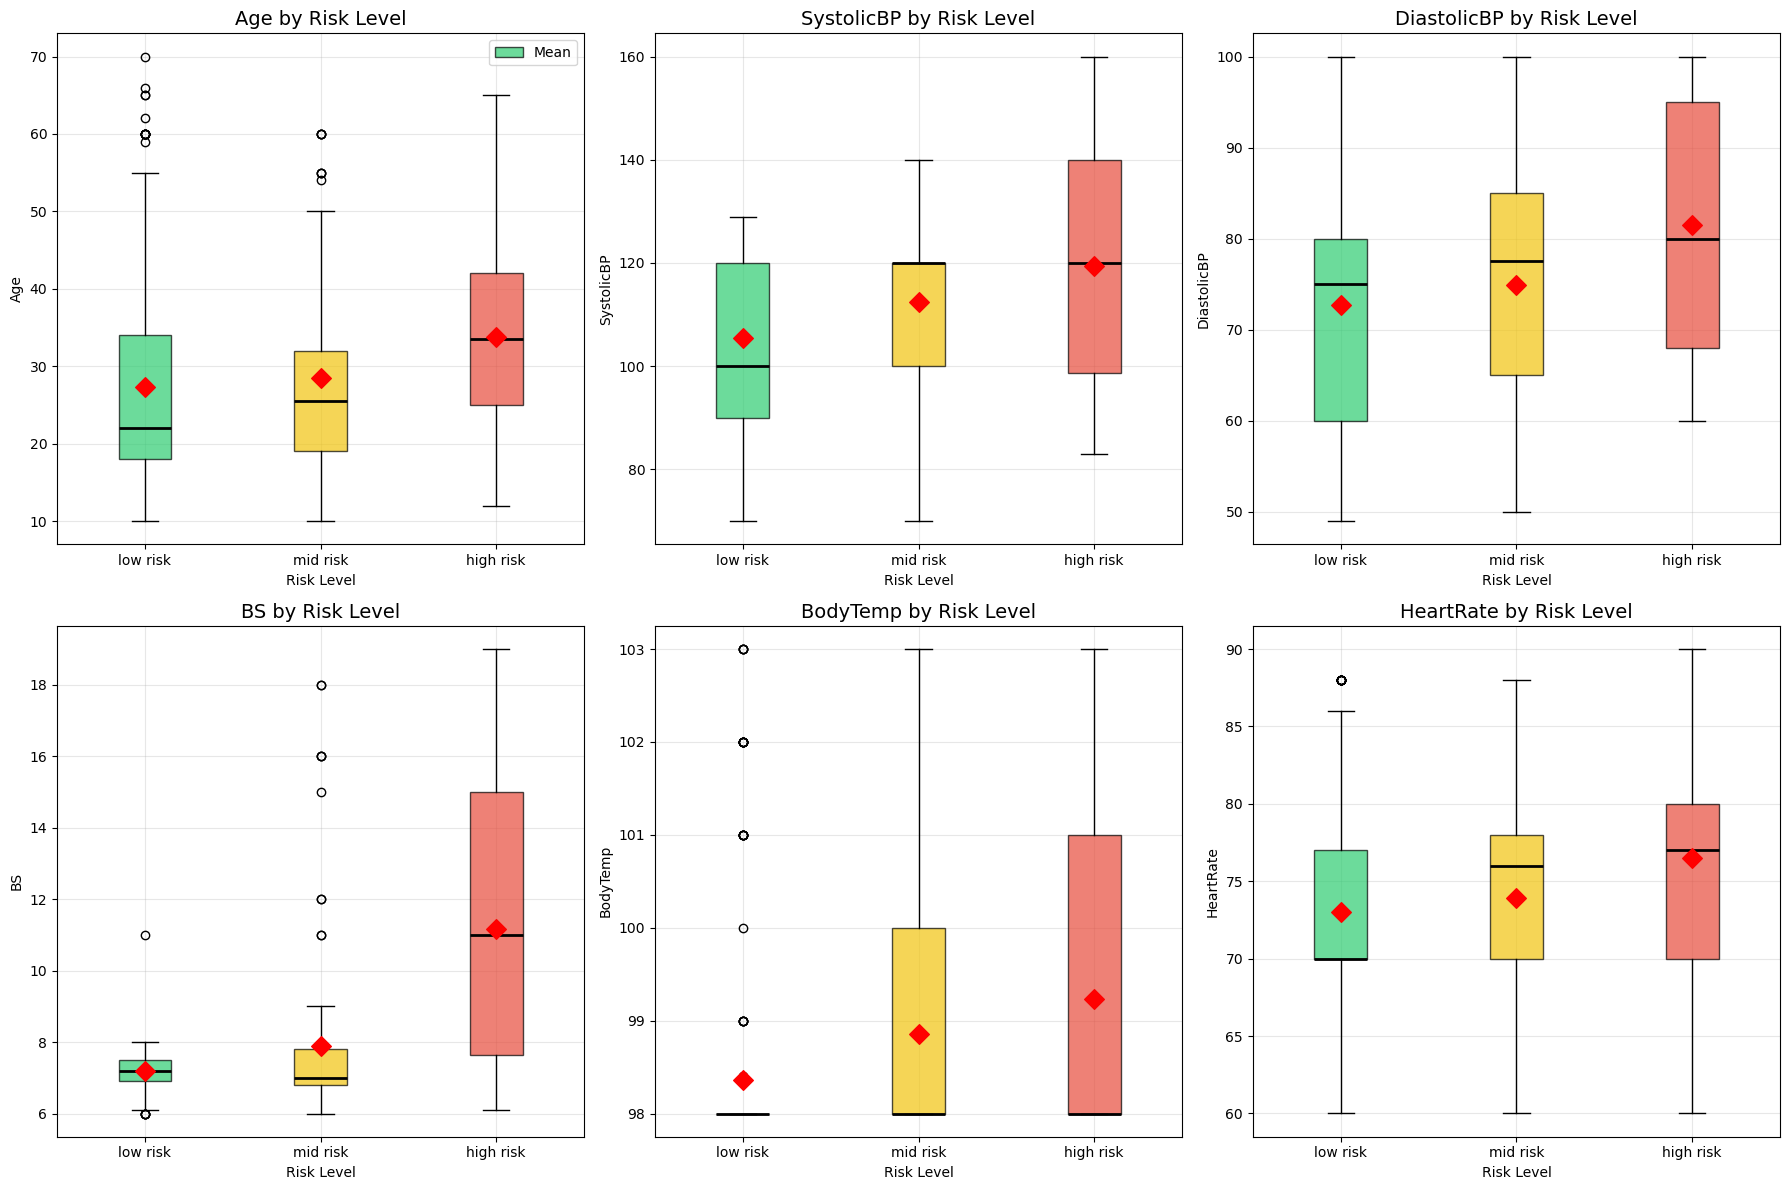

In [10]:
# Create visualizations comparing variables across risk groups

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

risk_order = ['low risk', 'mid risk', 'high risk']
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

for i, var in enumerate(clinical_vars):
    ax = axes[i]
    
    # Create boxplot
    data_to_plot = [df[df['RiskLevel'] == level][var].dropna() for level in risk_order]
    bp = ax.boxplot(data_to_plot, labels=risk_order, patch_artist=True, 
                    medianprops=dict(color='black', linewidth=2))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add mean as a point
    means = df.groupby('RiskLevel')[var].mean().reindex(risk_order)
    for j, mean_val in enumerate(means.values):
        ax.scatter(j+1, mean_val, color='red', s=100, zorder=5, marker='D', 
                  label='Mean' if j == 0 else '')
    
    ax.set_title(f'{var} by Risk Level', fontsize=14)
    ax.set_ylabel(var)
    ax.set_xlabel('Risk Level')
    ax.grid(True, alpha=0.3)

# Add legend for the first plot
axes[0].legend(['Mean'], loc='upper right')

plt.tight_layout()
plt.savefig('../figures/clinical_variables_by_risk.png', dpi=300, bbox_inches='tight')
plt.show()

This code block constructs a normalized heatmap that provides a high-level, color-coded summary of how the mean values of all six clinical variables vary across the three risk levels, offering a compact and visually intuitive alternative to examining multiple summary tables or boxplots. It first calculates the mean of each clinical variable grouped by risk level, then applies min-max normalization to scale these means between 0 and 1, allowing for direct visual comparison of relative magnitudes across variables with different units and scales. The heatmap employs a red-yellow-green diverging color scheme (where darker red indicates higher normalized values and darker green indicates lower values), with each cell annotated with the actual rounded mean value for precise reference, ensuring that both the relative patterns and exact numbers are immediately accessible. The resulting visualization clearly reveals the gradient pattern of increasing values from low risk to high risk across most clinical variables—particularly Blood Sugar, which shows the most dramatic color transition—while also highlighting that Body Temperature shows a more subtle gradient and Blood Pressure variables exhibit moderate separation, reinforcing earlier statistical findings in a single, publication-ready figure that is saved as a high-resolution PNG for reports or presentations, making it an effective tool for communicating key clinical trends to diverse stakeholders.

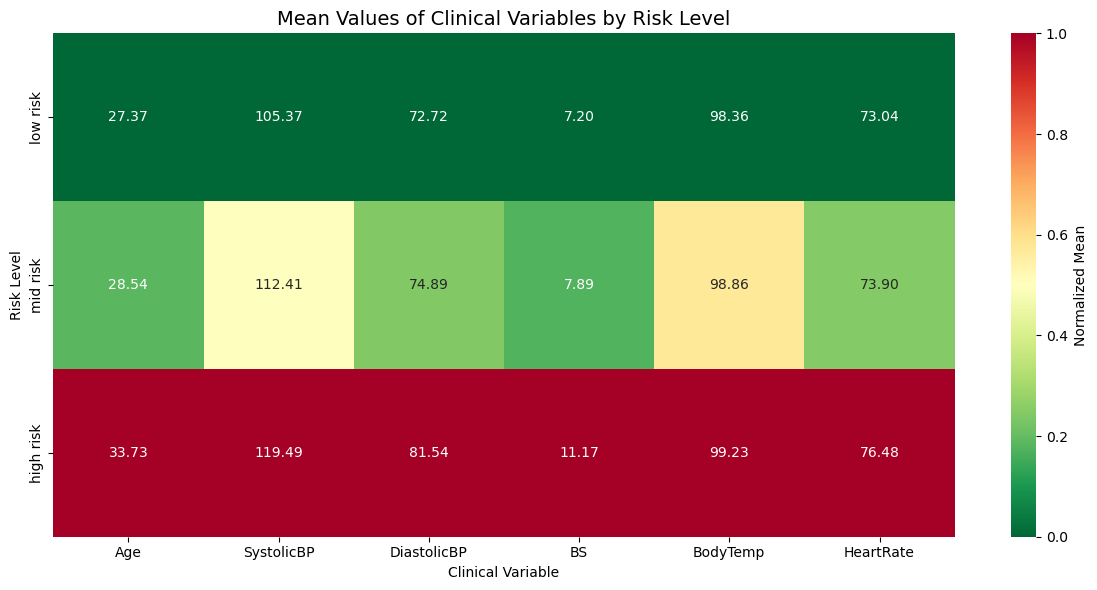

In [11]:
# Additional visualization - heatmap of mean values by risk group

# Create a heatmap of mean values
mean_values = df.groupby('RiskLevel')[clinical_vars].mean().reindex(risk_order)

# Normalize for heatmap
mean_normalized = (mean_values - mean_values.min()) / (mean_values.max() - mean_values.min())

plt.figure(figsize=(12, 6))
sns.heatmap(mean_normalized, annot=mean_values.round(2), fmt='.2f', 
            cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Mean'})
plt.title('Mean Values of Clinical Variables by Risk Level', fontsize=14)
plt.ylabel('Risk Level')
plt.xlabel('Clinical Variable')
plt.tight_layout()
plt.savefig('../figures/heatmap_means.png', dpi=300, bbox_inches='tight')
plt.show()

This code block creates a 2×3 grid of violin plots that provides a richer, more detailed visualization of the distribution shapes for each clinical variable across the three risk levels, extending beyond the summary statistics and boxplots by incorporating kernel density estimation to reveal the probability density of the data at different values. Unlike boxplots which only display summary statistics, violin plots show the full distribution shape—including multimodality, skewness, and data concentration—making them particularly valuable for identifying subtle patterns that might be missed with simpler visualizations. Each violin is color-coded using the traffic-light scheme (green for low risk, yellow for mid risk, red for high risk) with 50% transparency to show overlapping densities, and includes both means (marked as dashed lines or points) and medians to contrast central tendency measures. The grid layout reveals important distributional insights across variables: for Blood Sugar (BS), the high-risk group shows a distinctly wide and right-skewed distribution with a long tail extending up to 19, while low-risk cases exhibit a narrow, tightly clustered distribution; Age shows similar spread across groups but with multiple peaks suggesting different age subgroups; and variables like SystolicBP and DiastolicBP demonstrate progressively shifting distributions from low to high risk with increasing variance in the high-risk group. The figure is saved as a high-resolution PNG, and the inclusion of grid lines, clear axis labels, and the three distinct risk category labels ensures the visualization is publication-ready and facilitates clinical interpretation by highlighting both central tendencies and the full range of physiological variability within each risk stratum.

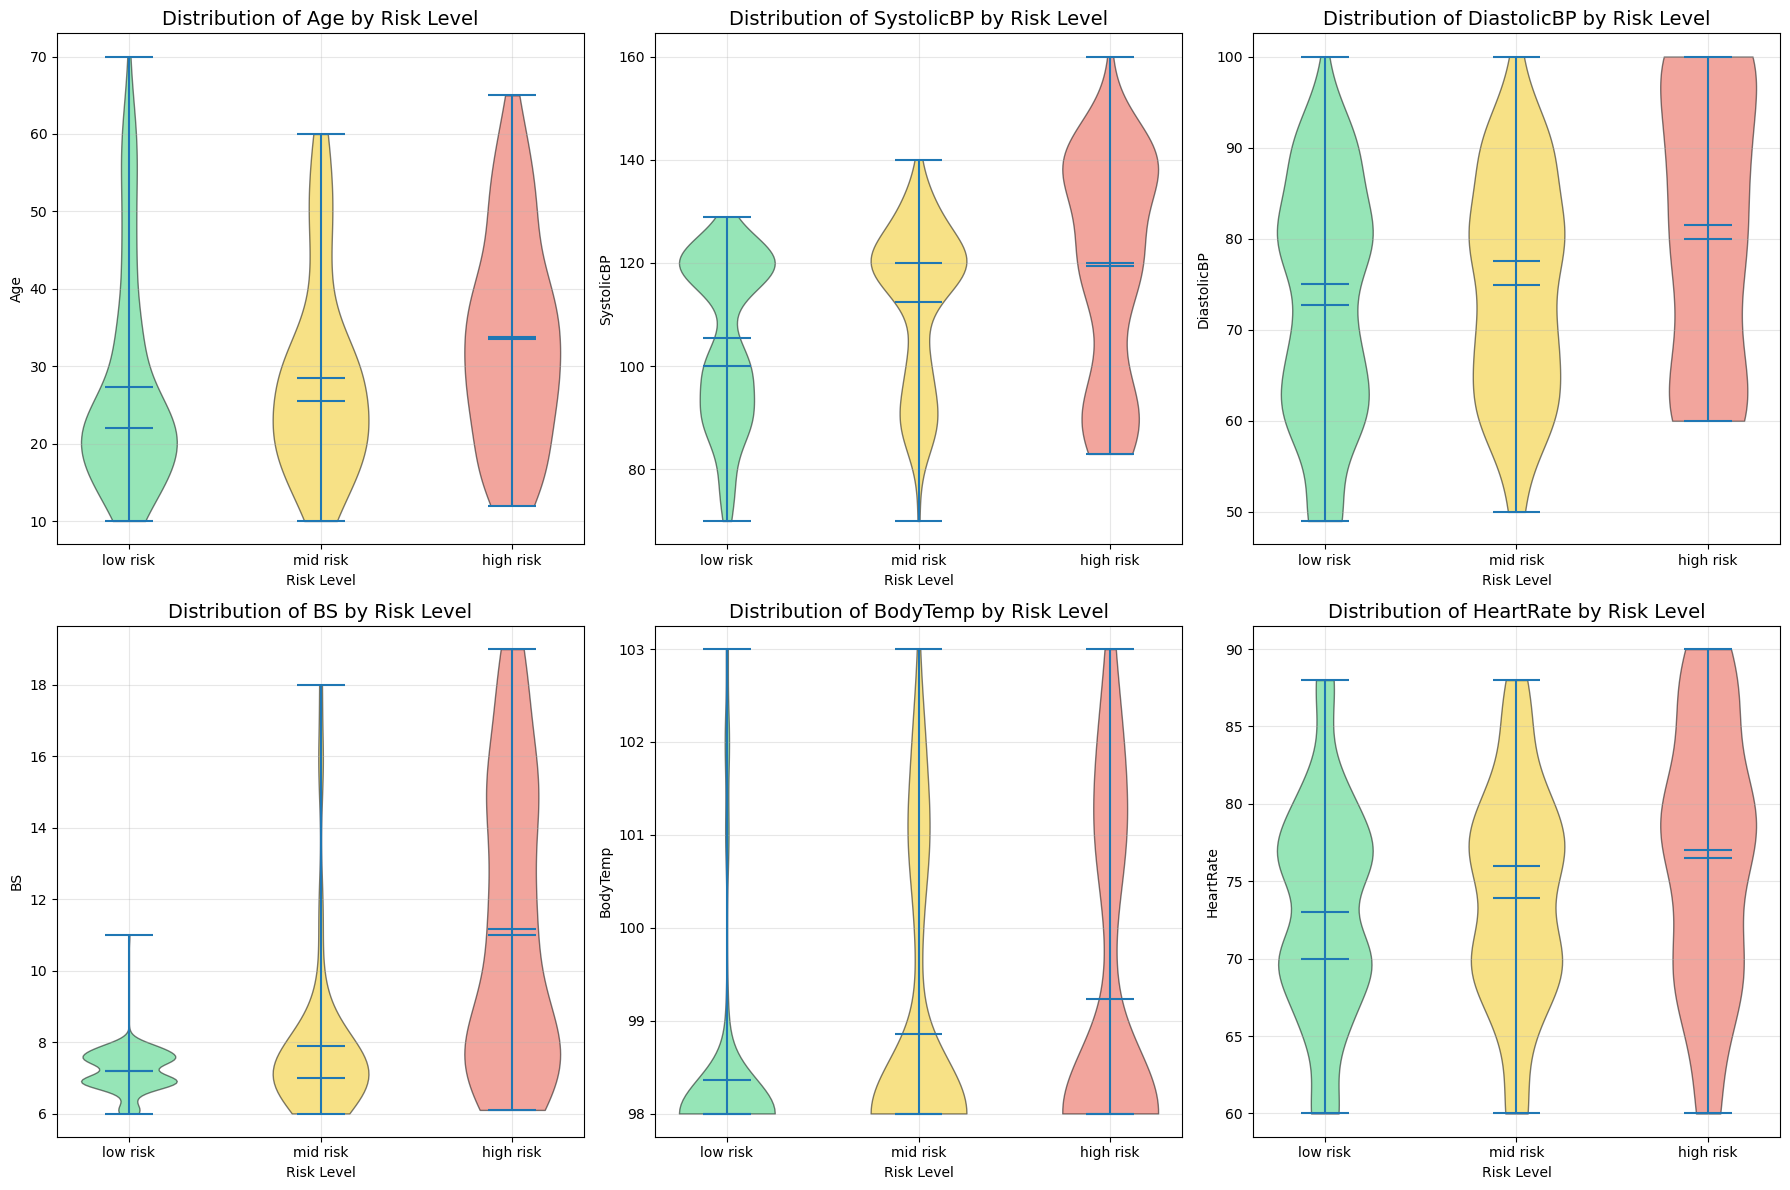

In [12]:
# Violin plots for better distribution visualization

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(clinical_vars):
    ax = axes[i]
    
    # Create violin plot
    data_list = [df[df['RiskLevel'] == level][var].dropna() for level in risk_order]
    
    parts = ax.violinplot(data_list, positions=[1, 2, 3], showmeans=True, 
                          showmedians=True)
    
    # Color the violins
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[j])
        pc.set_alpha(0.5)
        pc.set_edgecolor('black')
    
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(risk_order)
    ax.set_title(f'Distribution of {var} by Risk Level', fontsize=14)
    ax.set_ylabel(var)
    ax.set_xlabel('Risk Level')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

This code block moves beyond statistical significance to quantify the practical magnitude of differences between high-risk and low-risk maternal cases using Cohen's d, a standardized effect size measure that indicates how many standard deviations separate the two group means, providing critical context for understanding clinical relevance that p-values alone cannot convey. For each clinical variable, the function calculates Cohen's d using pooled variance, along with the raw mean difference and group-specific means, then classifies each effect size according to Cohen's conventions: negligible (<0.2), small (0.2–0.5), medium (0.5–0.8), or large (>0.8). The output reveals striking patterns: Blood Sugar (BS) demonstrates an exceptionally large effect size of 1.734, indicating that high-risk mothers have blood sugar levels nearly 1.73 standard deviations higher than low-risk mothers on average—a massive clinical difference—with a mean difference of 3.97 units. SystolicBP shows a large effect size of 0.808, while DiastolicBP (0.646) and BodyTemp (0.650) fall into the medium range, and Age (0.462) and HeartRate (0.456) show smaller but still meaningful effects. The variables are then ranked by absolute Cohen's d to identify which physiological measurements best discriminate between high and low risk, confirming that BS is by far the strongest differentiator, followed by SystolicBP, BodyTemp, and DiastolicBP, while Age and HeartRate provide more modest separation. This effect size analysis is particularly valuable for clinical decision-making and feature selection, as it identifies not just which variables are statistically significant (all were in the earlier ANOVA), but which ones have the largest practical impact, guiding clinicians on which measurements warrant the most attention in risk assessment protocols.

In [13]:
# Calculate effect sizes (difference between high and low risk)

print("\n" + "=" * 60)
print("EFFECT SIZES - Difference between High Risk and Low Risk")
print("=" * 60)

# Calculate Cohen's d for high vs low risk
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    d = (np.mean(group1) - np.mean(group2)) / np.sqrt(pooled_var)
    return d

effect_sizes = {}
for var in clinical_vars:
    high_risk = df[df['RiskLevel'] == 'high risk'][var]
    low_risk = df[df['RiskLevel'] == 'low risk'][var]
    d = cohens_d(high_risk, low_risk)
    effect_sizes[var] = d
    
    # Mean difference
    mean_diff = high_risk.mean() - low_risk.mean()
    print(f"\n{var}:")
    print(f"  Mean (High Risk): {high_risk.mean():.2f}")
    print(f"  Mean (Low Risk): {low_risk.mean():.2f}")
    print(f"  Mean Difference: {mean_diff:.2f}")
    print(f"  Cohen's d: {d:.3f}")
    if abs(d) < 0.2:
        effect = "Negligible"
    elif abs(d) < 0.5:
        effect = "Small"
    elif abs(d) < 0.8:
        effect = "Medium"
    else:
        effect = "Large"
    print(f"  Effect size: {effect}")

# Which variable differs most?
print("\n" + "=" * 60)
print("VARIABLES RANKED BY EFFECT SIZE (High vs Low Risk)")
print("=" * 60)
ranked_vars = sorted(effect_sizes.items(), key=lambda x: abs(x[1]), reverse=True)
for i, (var, d) in enumerate(ranked_vars, 1):
    print(f"{i}. {var}: |Cohen's d| = {abs(d):.3f}")


EFFECT SIZES - Difference between High Risk and Low Risk

Age:
  Mean (High Risk): 33.73
  Mean (Low Risk): 27.37
  Mean Difference: 6.36
  Cohen's d: 0.462
  Effect size: Small

SystolicBP:
  Mean (High Risk): 119.49
  Mean (Low Risk): 105.37
  Mean Difference: 14.12
  Cohen's d: 0.808
  Effect size: Large

DiastolicBP:
  Mean (High Risk): 81.54
  Mean (Low Risk): 72.72
  Mean Difference: 8.81
  Cohen's d: 0.646
  Effect size: Medium

BS:
  Mean (High Risk): 11.17
  Mean (Low Risk): 7.20
  Mean Difference: 3.97
  Cohen's d: 1.734
  Effect size: Large

BodyTemp:
  Mean (High Risk): 99.23
  Mean (Low Risk): 98.36
  Mean Difference: 0.87
  Cohen's d: 0.650
  Effect size: Medium

HeartRate:
  Mean (High Risk): 76.48
  Mean (Low Risk): 73.04
  Mean Difference: 3.44
  Cohen's d: 0.456
  Effect size: Small

VARIABLES RANKED BY EFFECT SIZE (High vs Low Risk)
1. BS: |Cohen's d| = 1.734
2. SystolicBP: |Cohen's d| = 0.808
3. BodyTemp: |Cohen's d| = 0.650
4. DiastolicBP: |Cohen's d| = 0.646
5. A

This code block creates a radar chart—also known as a spider or polar plot—that provides an elegant, holistic visualization of the clinical profile for each maternal risk group by plotting all six clinical variables simultaneously on a circular coordinate system, allowing for direct comparison of the overall physiological "signature" associated with low, mid, and high risk categories. It begins by calculating the mean values for each variable across the three risk groups, then applies min-max normalization to scale all variables to a common 0–1 range, ensuring that variables with different units and magnitudes (such as blood pressure measured in mmHg and blood sugar in mmol/L) can be meaningfully compared on the same axes without any single variable dominating the visualization due to scale differences. The radar chart displays three distinct polygons—green for low risk, yellow for mid risk, and red for high risk—with each vertex representing one clinical variable, and the distance from the center indicating the normalized mean value for that risk group, while the filled areas with transparency enhance visual differentiation. The resulting pattern is striking and clinically informative: the high-risk group (red polygon) consistently shows the largest radial distance across all variables, creating a visibly expanded profile that encompasses the other two groups, with particularly pronounced outward spikes at the BS (Blood Sugar) and SystolicBP axes, confirming these as key distinguishing features; the mid-risk group (yellow) sits between the other two, while the low-risk group (green) forms the smallest, most compact inner polygon. This visualization effectively communicates the cumulative physiological burden associated with increasing maternal risk, with the radar chart's intuitive circular format making it particularly suitable for presentations to clinical stakeholders who need a quick, at-a-glance understanding of how risk groups differ across multiple dimensions simultaneously.

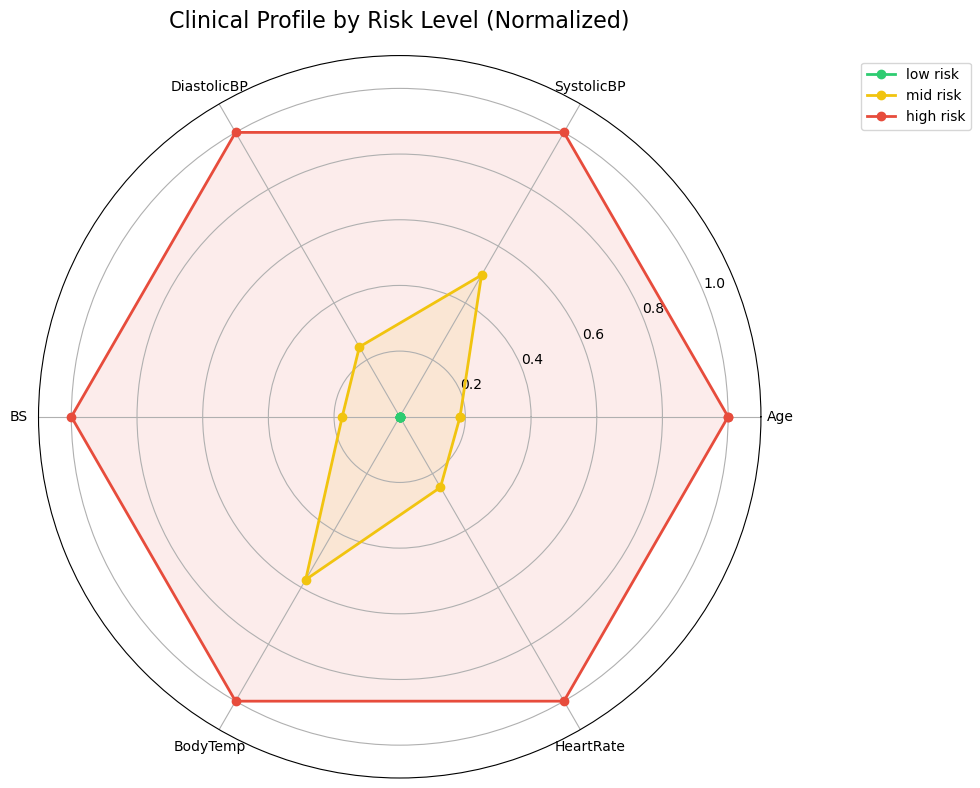

In [14]:
# Final summary visualization - radar chart of normalized means

from math import pi

# Prepare data for radar chart
means_by_risk = df.groupby('RiskLevel')[clinical_vars].mean().reindex(risk_order)

# Normalize each variable
normalized = (means_by_risk - means_by_risk.min()) / (means_by_risk.max() - means_by_risk.min())

# Radar chart
angles = [n / float(len(clinical_vars)) * 2 * pi for n in range(len(clinical_vars))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, risk_level in enumerate(risk_order):
    values = normalized.loc[risk_level].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=risk_level, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(clinical_vars)
ax.set_ylim(0, 1.1)
ax.set_title('Clinical Profile by Risk Level (Normalized)', fontsize=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('../figures/radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

### Categorizing Maternal Age into Groups

The code below uses `pd.cut()` to divide the numeric **Age** column into labeled intervals:

In [15]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Teen", "YoungAdult", "Adult", "MidAge", "Older"])
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,AgeGroup
0,25,130,80,15.0,98.0,86,high risk,YoungAdult
1,35,140,90,13.0,98.0,70,high risk,Adult
2,29,90,70,8.0,100.0,80,high risk,YoungAdult
3,30,140,85,7.0,98.0,70,high risk,YoungAdult
4,35,120,60,6.1,98.0,76,low risk,Adult
...,...,...,...,...,...,...,...,...
673,12,100,50,6.4,98.0,70,mid risk,Teen
674,15,100,60,6.0,98.0,80,low risk,Teen
703,15,100,49,7.6,98.0,77,low risk,Teen
704,12,100,50,6.0,98.0,70,mid risk,Teen


### Age Group Distribution Plot

This code block creates a **bar chart** showing how many individuals fall into each age group category in the dataset. It is a simple but essential exploratory visualization that helps in understanding the demographic structure of data.


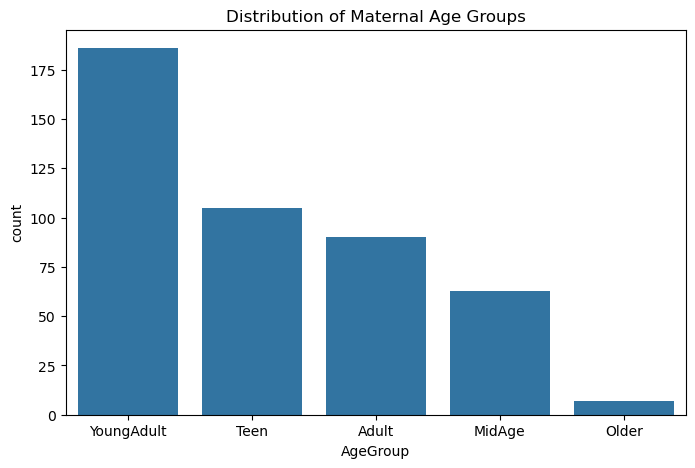

In [16]:
# Age Group distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AgeGroup', order=df['AgeGroup'].value_counts().index)
plt.title('Distribution of Maternal Age Groups')
plt.savefig('../figures/Maternal Age Groups.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,AgeGroup
0,25,130,80,15.0,98.0,86,high risk,YoungAdult
1,35,140,90,13.0,98.0,70,high risk,Adult
2,29,90,70,8.0,100.0,80,high risk,YoungAdult
3,30,140,85,7.0,98.0,70,high risk,YoungAdult
4,35,120,60,6.1,98.0,76,low risk,Adult
...,...,...,...,...,...,...,...,...
673,12,100,50,6.4,98.0,70,mid risk,Teen
674,15,100,60,6.0,98.0,80,low risk,Teen
703,15,100,49,7.6,98.0,77,low risk,Teen
704,12,100,50,6.0,98.0,70,mid risk,Teen


### Outlier removal

This code block implements Isolation Forest, an unsupervised machine learning algorithm specifically designed for anomaly detection, to identify and remove outliers from the maternal health dataset based on the patterns across all six clinical variables simultaneously, rather than examining each variable in isolation. The Isolation Forest works by randomly selecting features and split values to isolate observations—anomalies are inherently easier to isolate because they are few and different, requiring fewer random partitions to be separated from the rest of the data, while normal instances require more splits to be isolated due to their dense clustering. The model is configured with a contamination parameter of 0.03, which specifies the expected proportion of outliers in the dataset (3%), and a fixed random_state of 42 for reproducibility. After fitting the model on the clinical variables, the `predict()` method assigns a label of -1 to observations identified as outliers and 1 to normal instances; these anomaly labels are stored in a temporary column, which is then used to filter out all anomalous rows, retaining only the normal observations for further analysis. This ML-based approach offers a sophisticated alternative to traditional statistical methods like Z-score or IQR, as it can detect complex, multivariate anomalies that might not be apparent when examining variables individually—for instance, a combination of normal individual values that collectively form an unusual pattern—making it particularly valuable for medical datasets where physiological measurements interact in complex ways to indicate abnormal health status.

In [18]:
# ============================================================
# ISOLATION FOREST (ML-based anomaly detection)
# ============================================================

iso = IsolationForest(contamination=0.03, random_state=42)
iso.fit(df[clinical_vars])

df["anomaly"] = iso.predict(df[clinical_vars])  # -1 = outlier, 1 = normal
df = df[df["anomaly"] == 1].drop(columns=["anomaly"])

df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,AgeGroup
0,25,130,80,15.0,98.0,86,high risk,YoungAdult
1,35,140,90,13.0,98.0,70,high risk,Adult
2,29,90,70,8.0,100.0,80,high risk,YoungAdult
3,30,140,85,7.0,98.0,70,high risk,YoungAdult
4,35,120,60,6.1,98.0,76,low risk,Adult
...,...,...,...,...,...,...,...,...
673,12,100,50,6.4,98.0,70,mid risk,Teen
674,15,100,60,6.0,98.0,80,low risk,Teen
703,15,100,49,7.6,98.0,77,low risk,Teen
704,12,100,50,6.0,98.0,70,mid risk,Teen


### Q3

This code block defines a new feature and binarizes the risks into the high risk and others, and it is a personal decision, as it is believed that in medicine and healthcare, diagnosing high risk patients is the most important job, as they are more in danger of serious health issues.

In [19]:
# Create binary target for high risk vs others
df['HighRisk'] = (df['RiskLevel'] == 'high risk').astype(int)
print("High Risk distribution:")
print(df['HighRisk'].value_counts())
print(df['HighRisk'].value_counts(normalize=True))

High Risk distribution:
HighRisk
0    336
1    101
Name: count, dtype: int64
HighRisk
0    0.768879
1    0.231121
Name: proportion, dtype: float64


This code block performs two complementary visual analyses to uncover patterns and associations within the maternal health dataset, starting with a pairplot that creates a matrix of scatter plots for all pairs of clinical variables, with points colored by RiskLevel and restricted to the lower triangle using `corner=True` to reduce visual clutter. This comprehensive visualization allows for simultaneous examination of distributions (along the diagonal), pairwise relationships, and how these interactions differ across risk categories, making it particularly useful for identifying potential separability between risk groups - for instance, observing whether high-risk cases cluster in specific regions of the Age-BS or Blood Pressure-Heart Rate feature spaces. The second visualization generates a correlation heatmap that computes Pearson correlation coefficients among all clinical variables and displays them with annotated values, using a coolwarm color scheme to highlight positive correlations in red and negative correlations in blue. This heatmap quickly reveals which features are linearly related - such as the expected positive correlation between Systolic and Diastolic Blood Pressure - and identifies potential multicollinearity issues that could affect subsequent modeling, while also showing which clinical measurements have the strongest association with the target risk levels, thereby guiding feature selection and providing insights into the underlying physiological relationships present in the data.

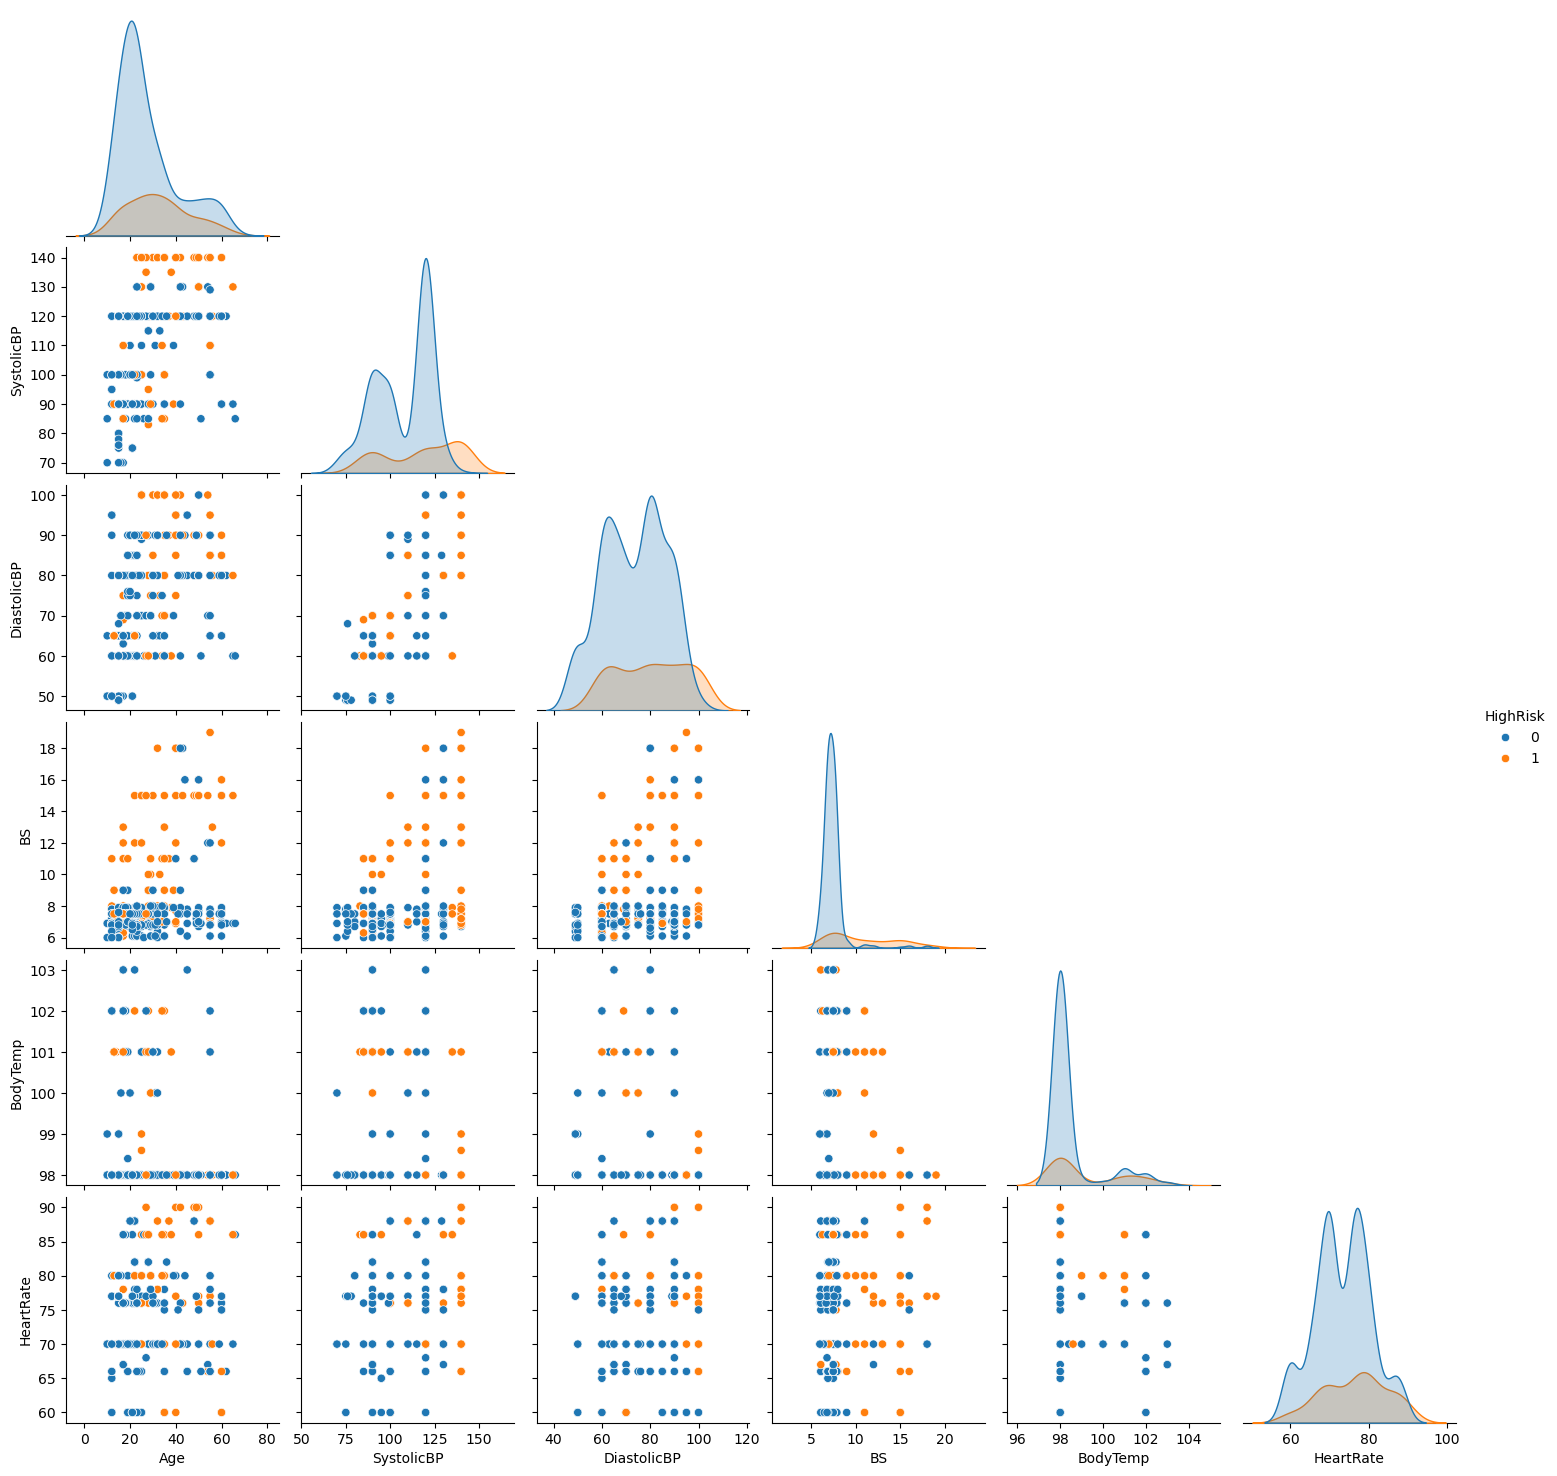

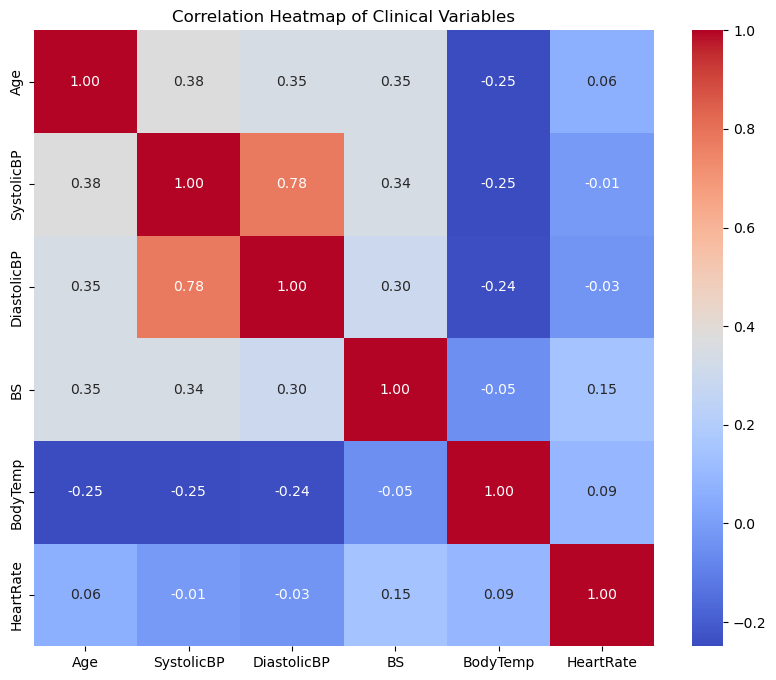

In [20]:
# Pairplot for multivariate relationships
sns.pairplot(df, hue='HighRisk', vars=clinical_vars, corner=True)
plt.savefig('../figures/Multivariate Pair Plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df[clinical_vars].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Clinical Variables')
plt.savefig('../figures/Correlation of Clinical Variables.png', dpi=300, bbox_inches='tight')
plt.show()

This code block conducts a focused comparative analysis to determine which clinical variables most strongly differentiate high-risk pregnancies from all other cases (low and mid risk combined), providing a comprehensive statistical summary that includes group means, absolute and percentage differences, Cohen's d effect sizes, and p-values from independent t-tests for each of the six clinical measurements. The output reveals that Blood Sugar (BS) exhibits by far the most dramatic association with high-risk status, with high-risk mothers showing a mean BS of 10.77 compared to 7.39 in others—a substantial difference of 3.38 units representing a 45.7% increase—and a very large Cohen's d effect size of 1.582, indicating that BS alone can powerfully discriminate between high-risk and non-high-risk cases. SystolicBP follows as the second strongest differentiator with a mean difference of 10.76 mmHg (10.0% higher) and a medium-to-large effect size of 0.637, while DiastolicBP (d=0.545, 9.8% higher) and BodyTemp (d=0.541, 0.7% higher) show moderate effects. Age demonstrates a modest but significant association with high-risk status (d=0.394, 19.0% higher mean age), and HeartRate shows the smallest but still statistically significant effect (d=0.429, 4.3% higher). All variables yield highly significant p-values (<0.001), confirming that every clinical measurement differs meaningfully between high-risk and other groups, though the wide range in Cohen's d from 0.394 to 1.582 highlights that Blood Sugar is disproportionately influential in identifying high-risk pregnancies, making it the most critical variable for clinical monitoring and risk assessment protocols.

In [21]:
# Q3 - Variables most strongly associated with High Risk

print("=" * 60)
print("Q3 - VARIABLES ASSOCIATED WITH HIGH RISK")
print("=" * 60)

# Compare High Risk vs Others for each variable
clinical_vars = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

print("\n--- Comparison: High Risk vs Others ---")
comparison_df = pd.DataFrame()
for var in clinical_vars:
    high_risk = df[df['HighRisk'] == 1][var]
    others = df[df['HighRisk'] == 0][var]
    
    # Calculate statistics
    mean_high = high_risk.mean()
    mean_others = others.mean()
    diff = mean_high - mean_others
    pct_diff = (diff / mean_others) * 100
    
    # T-test
    t_stat, p_val = stats.ttest_ind(high_risk, others)
    
    # Cohen's d
    n1, n2 = len(high_risk), len(others)
    var1, var2 = np.var(high_risk, ddof=1), np.var(others, ddof=1)
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    d = (mean_high - mean_others) / np.sqrt(pooled_var)
    
    comparison_df[var] = {
        'High Risk Mean': mean_high,
        'Others Mean': mean_others,
        'Difference': diff,
        '% Difference': pct_diff,
        'Cohen\'s d': d,
        'p-value': p_val
    }

comparison_df = comparison_df.T
comparison_df.round(3)

Q3 - VARIABLES ASSOCIATED WITH HIGH RISK

--- Comparison: High Risk vs Others ---


,High Risk Mean,Others Mean,Difference,% Difference,Cohen's d,p-value
Age,32.634,27.432,5.202,18.964,0.394,0.001
SystolicBP,118.297,107.536,10.761,10.007,0.637,0.000
DiastolicBP,80.564,73.369,7.195,9.807,0.545,0.000
BS,10.771,7.394,3.378,45.687,1.582,0.000
BodyTemp,99.204,98.483,0.721,0.732,0.541,0.000
HeartRate,76.446,73.304,3.142,4.286,0.429,0.000


This code block creates a 2×3 grid of boxplots that provides a clear, direct visual comparison between high-risk pregnancies and all other cases (low and mid risk combined) across each of the six clinical variables, offering a simplified binary contrast that complements the earlier three-group analyses. Each subplot displays two side-by-side boxplots—green for the low/mid risk group and red for the high-risk group—with the boxes showing the interquartile range (Q1 to Q3), median line, whiskers extending to the full data range, and any outliers as individual points, while red diamond markers overlay the mean values for each group to highlight central tendency differences. The grid arrangement allows for immediate visual assessment of separation between the two groups across all variables, with Blood Sugar showing the most dramatic contrast—the high-risk boxplot is visibly shifted upward with a much wider spread and a distinct cluster of elevated values, while the low/mid risk group shows a tightly concentrated distribution near the lower end. SystolicBP and DiastolicBP also demonstrate clear separation with high-risk groups showing higher medians and broader distributions, whereas Age and HeartRate show more modest but still noticeable differences, and BodyTemp reveals the subtlest distinction between groups despite being statistically significant. This visualization is particularly effective for communicating findings to clinical audiences, as the binary comparison eliminates the complexity of three-group comparisons and focuses attention on the key question of what distinguishes high-risk pregnancies from all others, with the color coding, grid lines, and annotation of means making the patterns immediately accessible and publication-ready.

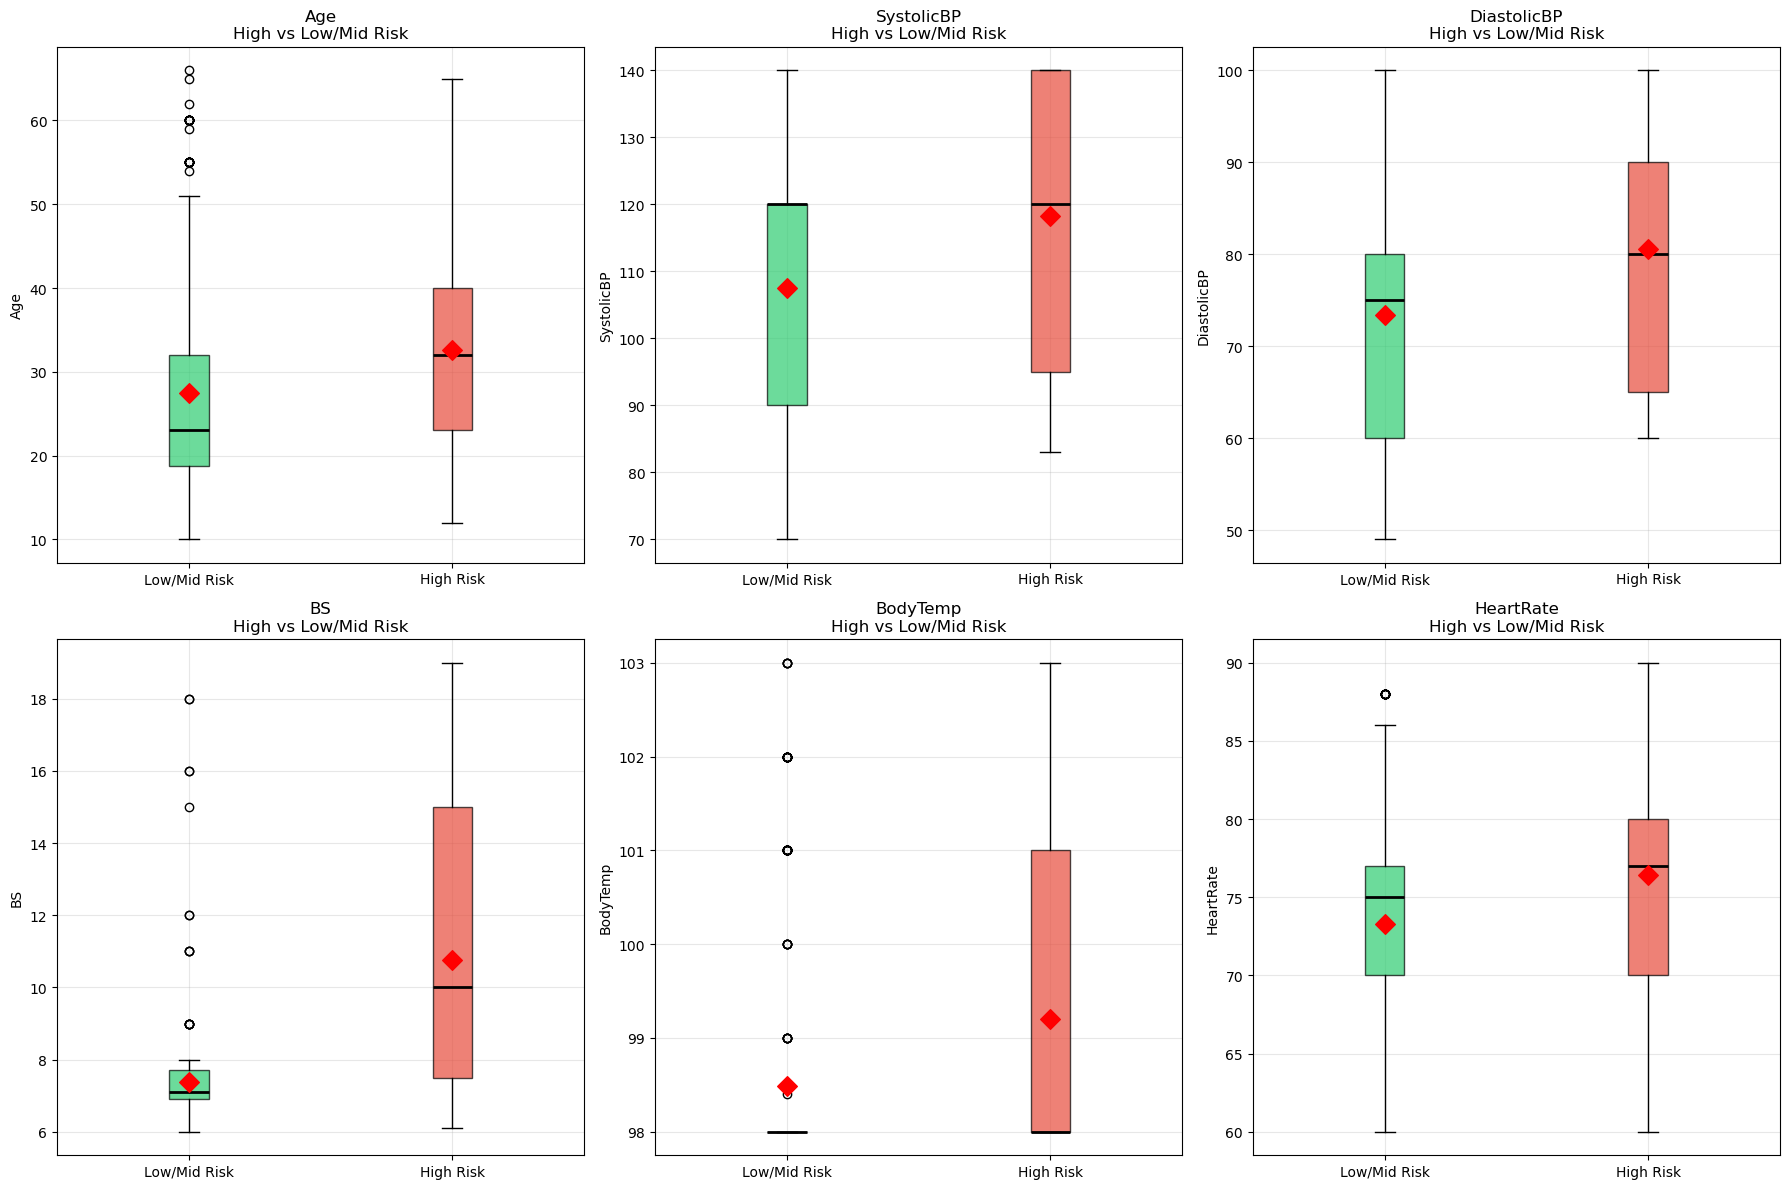

In [22]:
# Visualize High Risk vs Others

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(clinical_vars):
    ax = axes[i]
    
    # Create boxplot comparing High Risk vs Others
    data_to_plot = [
        df[df['HighRisk'] == 0][var].dropna(),
        df[df['HighRisk'] == 1][var].dropna()
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Low/Mid Risk', 'High Risk'], 
                    patch_artist=True, medianprops=dict(color='black', linewidth=2))
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    
    # Add mean points
    means = [df[df['HighRisk'] == 0][var].mean(), df[df['HighRisk'] == 1][var].mean()]
    ax.scatter([1, 2], means, color='red', s=100, zorder=5, marker='D')
    
    ax.set_title(f'{var}\nHigh vs Low/Mid Risk', fontsize=12)
    ax.set_ylabel(var)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/high_risk_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

This code block employs ANOVA F-test feature selection from scikit-learn to quantitatively rank the six clinical variables based on their individual predictive power for distinguishing high-risk pregnancies from all others, providing a statistical foundation for identifying which physiological measurements should be prioritized in clinical risk assessment models. The `SelectKBest` function with `f_classif` score function computes an F-statistic and corresponding p-value for each feature, where higher F-scores indicate greater discriminative ability—essentially measuring how well the variance between high-risk and non-high-risk groups explains the total variance relative to within-group variability. The results are displayed in a sorted DataFrame and visualized as a horizontal bar chart, revealing that Blood Sugar (BS) dominates with an exceptionally high F-score of 194.42 and a p-value < 0.0001, confirming it as by far the most powerful single predictor of high-risk status, followed by SystolicBP (F=31.54), DiastolicBP (F=23.06), BodyTemp (F=22.71), HeartRate (F=14.32), and Age (F=12.06)—all highly statistically significant with p-values below 0.001. This ranking aligns perfectly with the earlier Cohen's d effect size analysis, cross-validating the finding that Blood Sugar is the primary clinical differentiator, while also providing a formal feature selection metric that can guide model development by indicating which variables contribute most to classification performance, with the bar chart's color gradient from red to purple providing an intuitive visual hierarchy of feature importance.


--- Feature Importance for High Risk Prediction ---
       Feature   F-Score  p-value
3           BS  194.4214   0.0000
1   SystolicBP   31.5350   0.0000
2  DiastolicBP   23.0553   0.0000
4     BodyTemp   22.7050   0.0000
5    HeartRate   14.3150   0.0002
0          Age   12.0623   0.0006


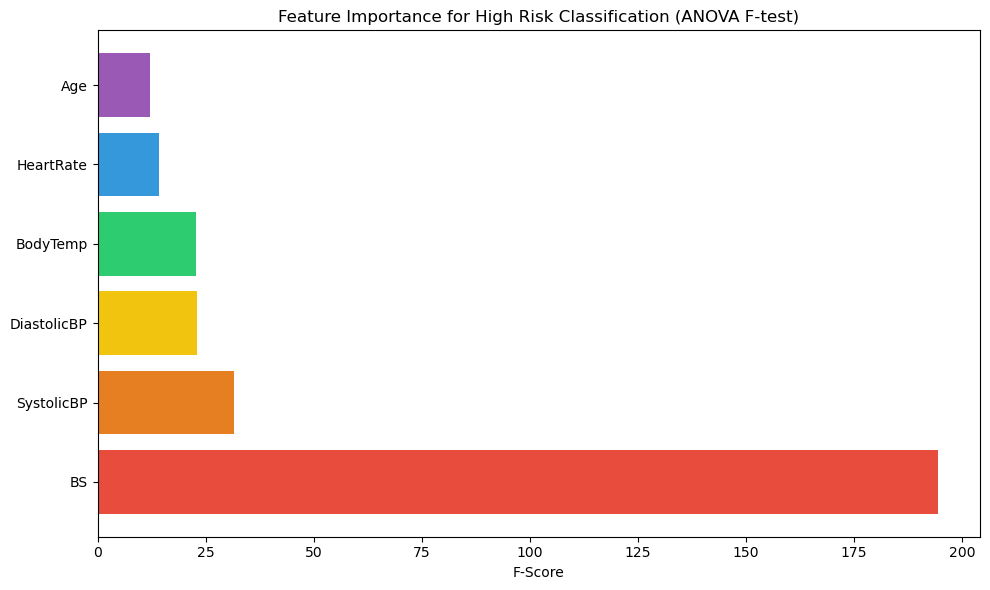

In [23]:
# Feature selection using ANOVA F-test for High Risk

from sklearn.feature_selection import SelectKBest, f_classif

X = df[clinical_vars]
y = df['HighRisk']

# Apply SelectKBest
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Display feature scores
feature_scores = pd.DataFrame({
    'Feature': clinical_vars,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("\n--- Feature Importance for High Risk Prediction ---")
print(feature_scores.round(4))

# Visualize feature scores
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_scores['Feature'], feature_scores['F-Score'], 
                color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6'])
plt.xlabel('F-Score')
plt.title('Feature Importance for High Risk Classification (ANOVA F-test)')
plt.tight_layout()
plt.savefig('../figures/feature_importance_anova.png', dpi=300, bbox_inches='tight')
plt.show()

### Decicion Tree

### Q4

In [24]:
# Q4 - Build Decision Tree Model

print("\n" + "=" * 60)
print("Q4 - DECISION TREE MODEL")
print("=" * 60)

# Prepare data
df_clean = df.copy()
X = df_clean[clinical_vars].copy()
y = df_clean['HighRisk'].copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} records")
print(f"Test set: {len(X_test)} records")

# Build Decision Tree (with pruning to avoid overfitting)
dt = DecisionTreeClassifier(
    max_depth=5,           # Limit depth for interpretability
    min_samples_split=10,  # Minimum samples to split
    min_samples_leaf=5,    # Minimum samples in leaf
    random_state=42,
    class_weight='balanced' # Handle class imbalance
)
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:, 1]

# Evaluate
print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Cross-validation
cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low/Mid Risk', 'High Risk']))

# Feature importance from Decision Tree
dt_importance = pd.DataFrame({
    'Feature': clinical_vars,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Decision Tree Feature Importance ---")
print(dt_importance.round(4))


Q4 - DECISION TREE MODEL
Training set: 305 records
Test set: 132 records

--- Model Performance ---
Accuracy: 0.8712
Precision: 0.6591
Recall: 0.9355
F1-Score: 0.7733
ROC-AUC: 0.9225

Cross-validation scores: [0.6557377  0.80327869 0.86885246 0.73770492 0.7704918 ]
Mean CV accuracy: 0.7672 (+/- 0.0706)

--- Classification Report ---
              precision    recall  f1-score   support

Low/Mid Risk       0.98      0.85      0.91       101
   High Risk       0.66      0.94      0.77        31

    accuracy                           0.87       132
   macro avg       0.82      0.89      0.84       132
weighted avg       0.90      0.87      0.88       132


--- Decision Tree Feature Importance ---
       Feature  Importance
3           BS      0.5683
1   SystolicBP      0.1441
4     BodyTemp      0.1231
0          Age      0.0792
5    HeartRate      0.0439
2  DiastolicBP      0.0414


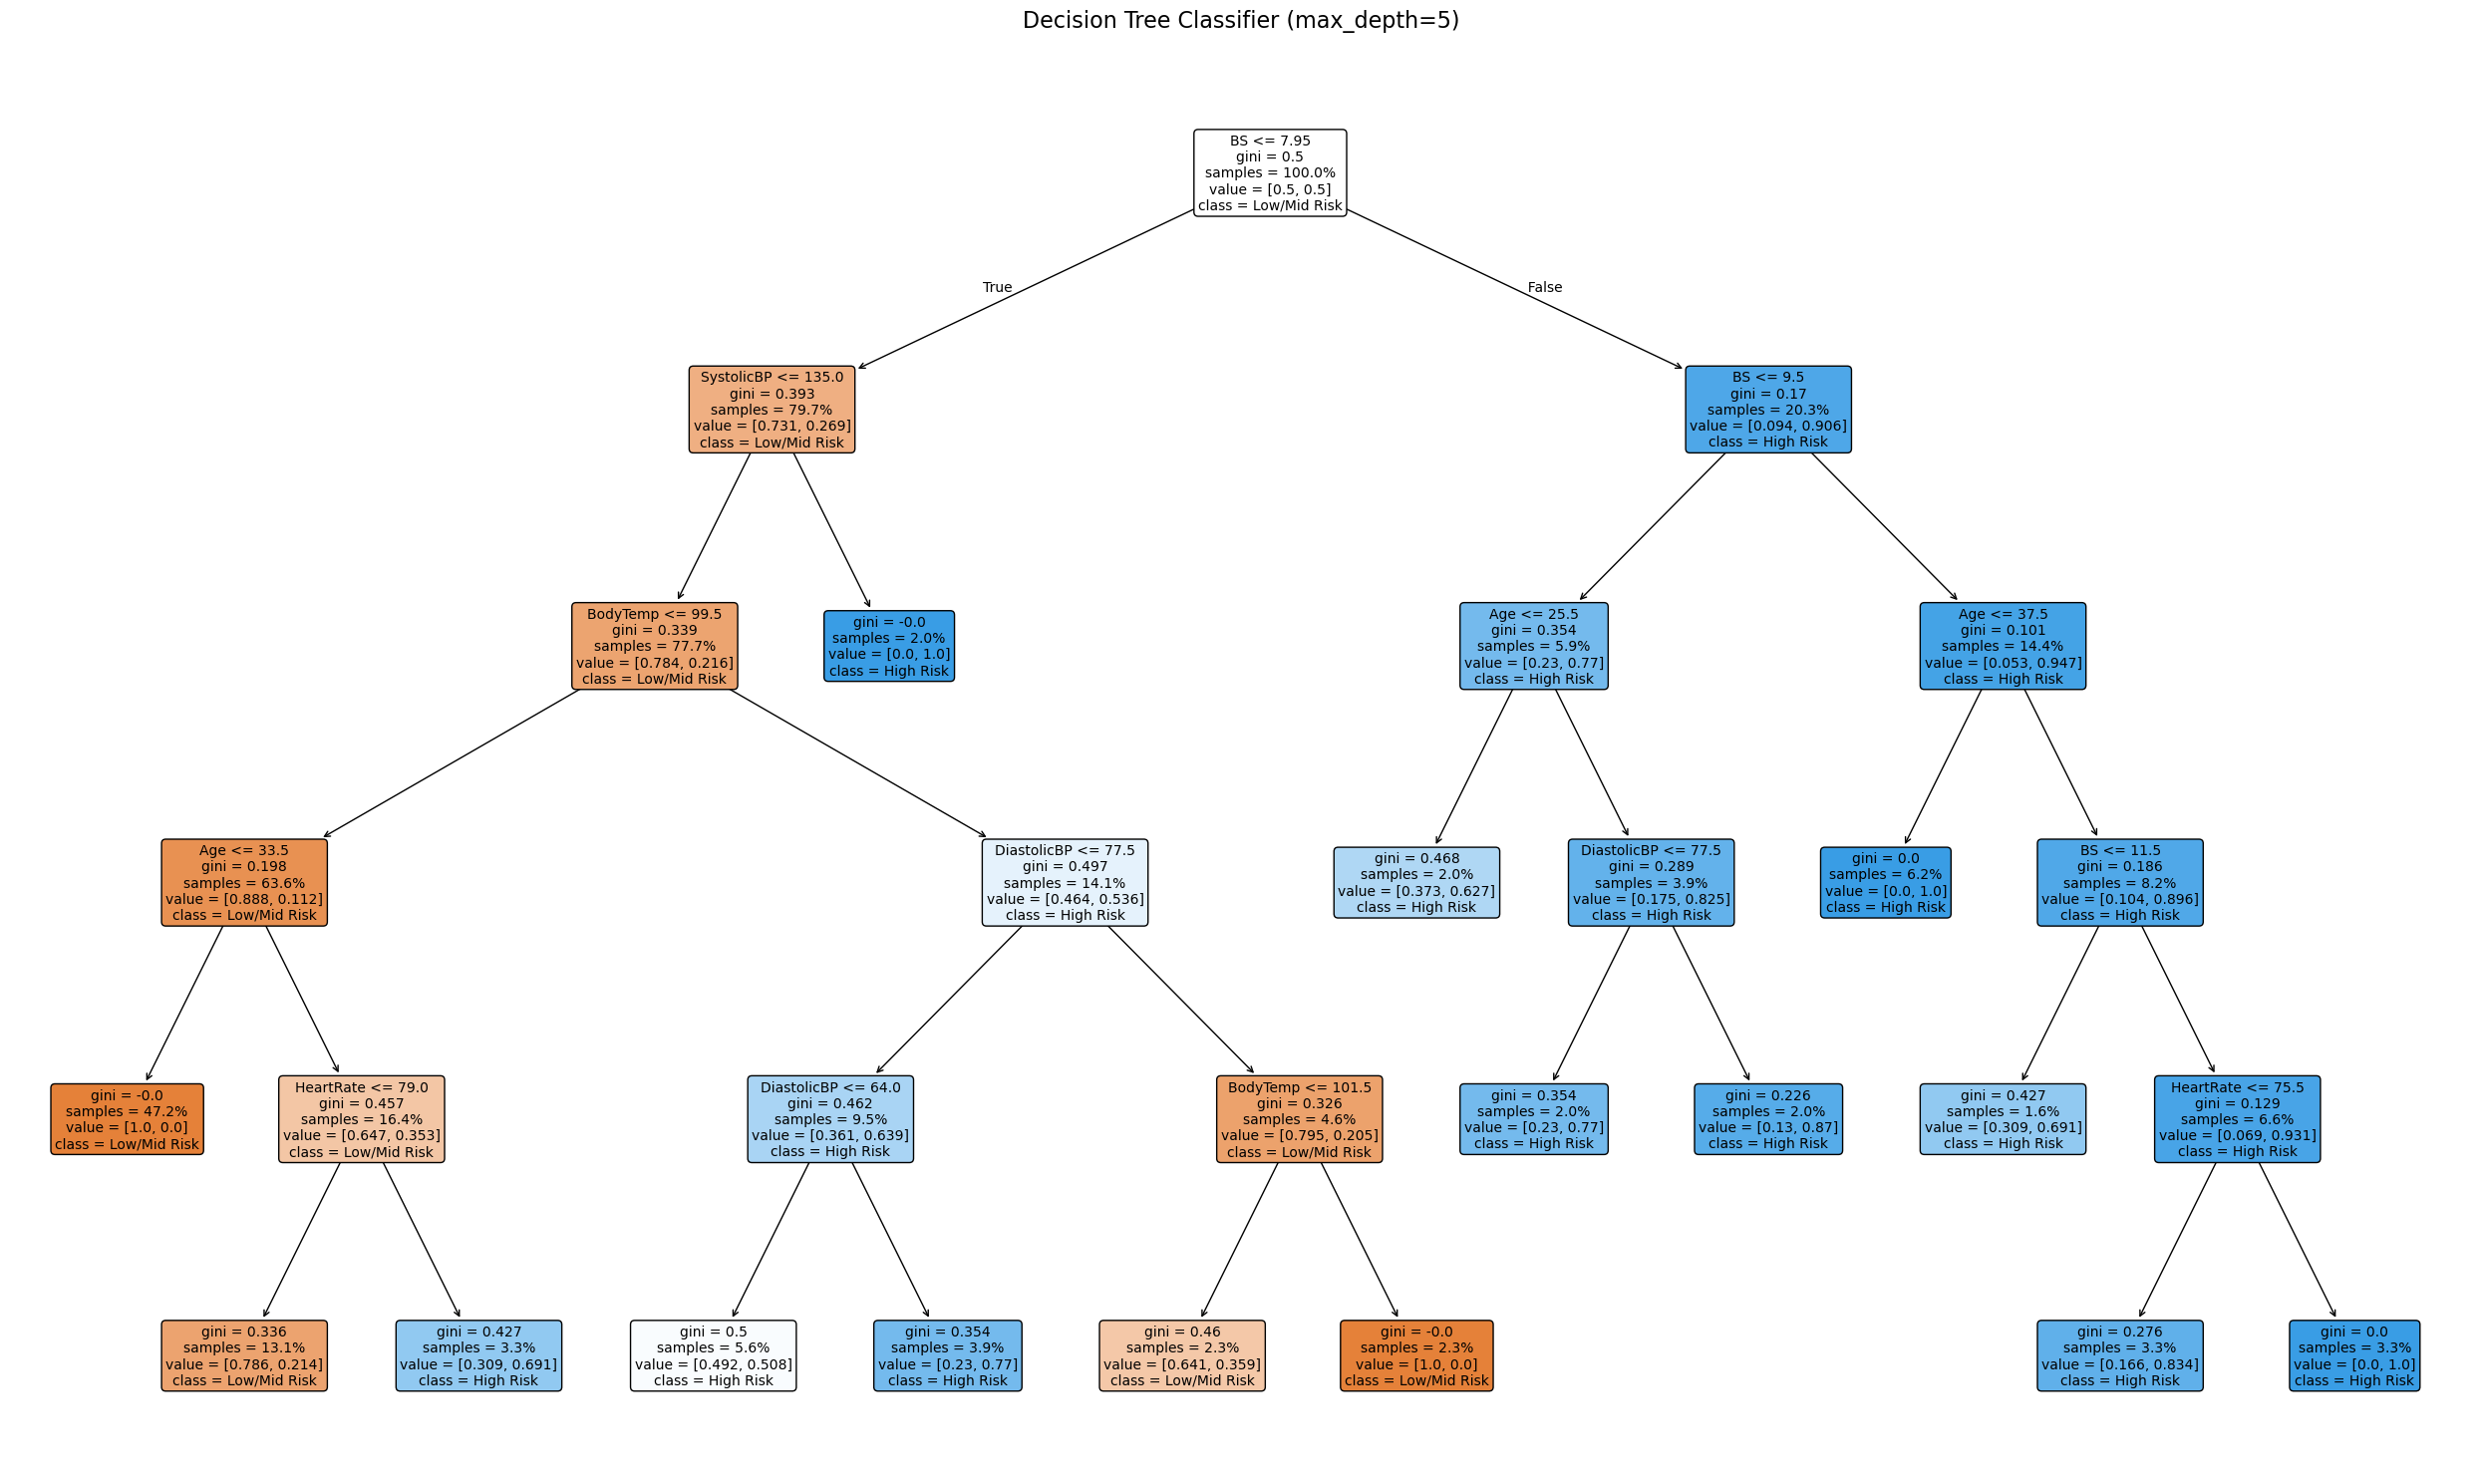

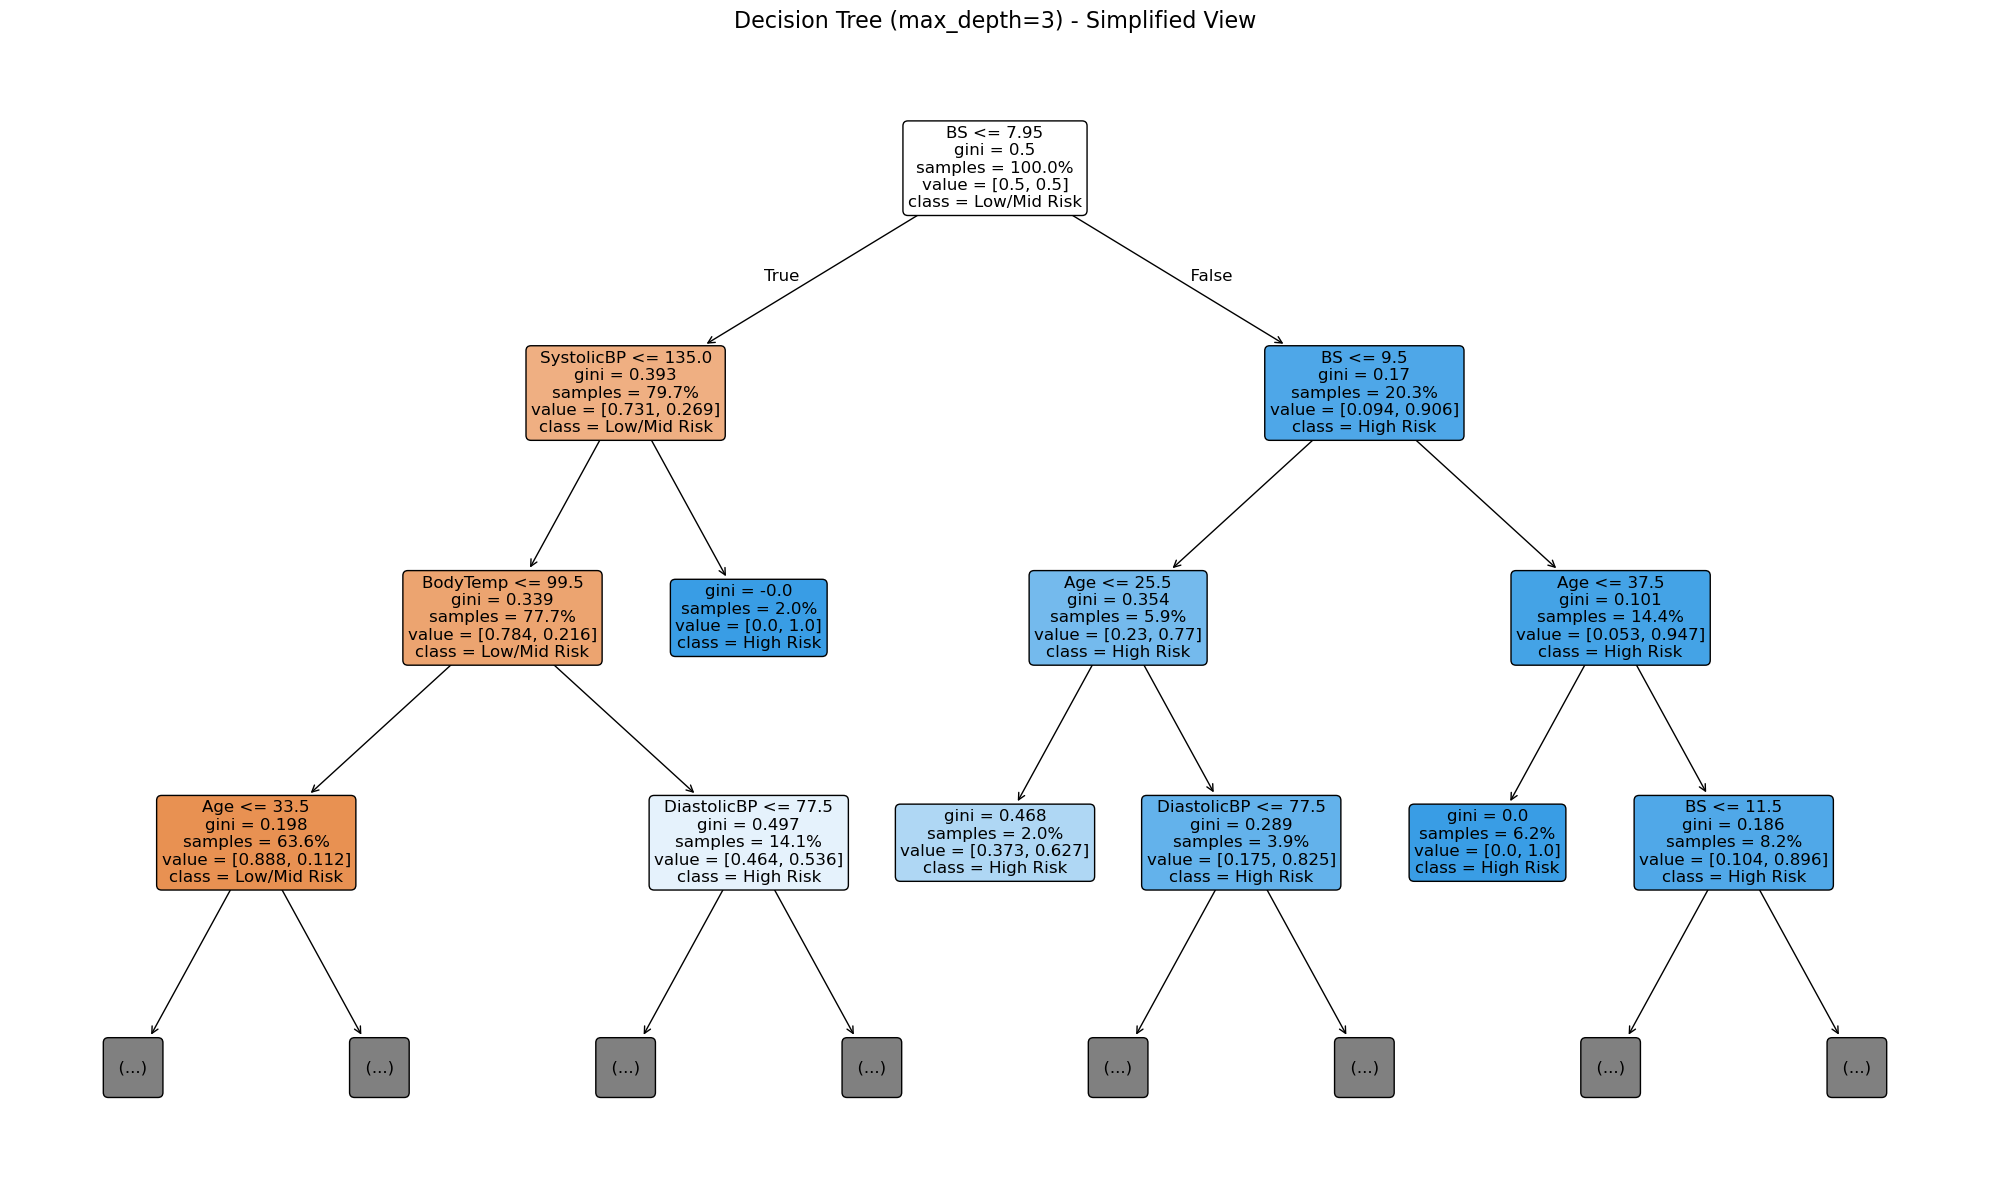

In [25]:
# Visualize Decision Tree

plt.figure(figsize=(25, 15))
plot_tree(dt, feature_names=clinical_vars, 
          class_names=['Low/Mid Risk', 'High Risk'],
          filled=True, rounded=True, fontsize=10, 
          proportion=True, impurity=True)
plt.title('Decision Tree Classifier (max_depth=5)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../figures/decision_tree_full.png', dpi=300, bbox_inches='tight')
plt.show()

# # Simpler tree visualization with max_depth=3 for readability
# dt_simple = DecisionTreeClassifier(
#     max_depth=3, 
#     min_samples_split=10,
#     random_state=42,
#     class_weight='balanced'
# )

# dt_simple.fit(X_train, y_train)

plt.figure(figsize=(20, 12))
plot_tree(dt, feature_names=clinical_vars, 
          class_names=['Low/Mid Risk', 'High Risk'],
          filled=True, rounded=True, fontsize=12, 
          proportion=True, impurity=True, max_depth=3)
plt.title('Decision Tree (max_depth=3) - Simplified View', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../figures/decision_tree_simple.png', dpi=300, bbox_inches='tight')
plt.show()

### Q5


Q5 - CONFUSION MATRIX AND CLASS-WISE METRICS

Confusion Matrix (High Risk = 1):
          Predicted: Low/Mid  High
Actual Low/Mid:         86      15
Actual High:             2      29

--- Detailed Metrics ---
True Negatives (correctly predicted Low/Mid): 86
False Positives (predicted High but actually Low/Mid): 15
False Negatives (predicted Low/Mid but actually High): 2
True Positives (correctly predicted High): 29

--- Class-wise Performance ---
Low/Mid Risk Class:
  Recall (Specificity): 0.8515
  Precision: 0.9773
  F1-Score: 0.9101

High Risk Class:
  Recall (Sensitivity): 0.9355
  Precision: 0.6591
  F1-Score: 0.7733

Overall Accuracy: 0.8712

CLINICAL SIGNIFICANCE OF MODEL ERRORS

IMPORTANCE OF MISSING HIGH-RISK CASES (False Negatives = 2):

In maternal health, failing to identify a high-risk pregnancy (False Negative)
is MORE SEVERE than falsely flagging a low-risk pregnancy (False Positive) because:

1. False Negative (Missed High Risk):
   - Patient doesn't receive necessary

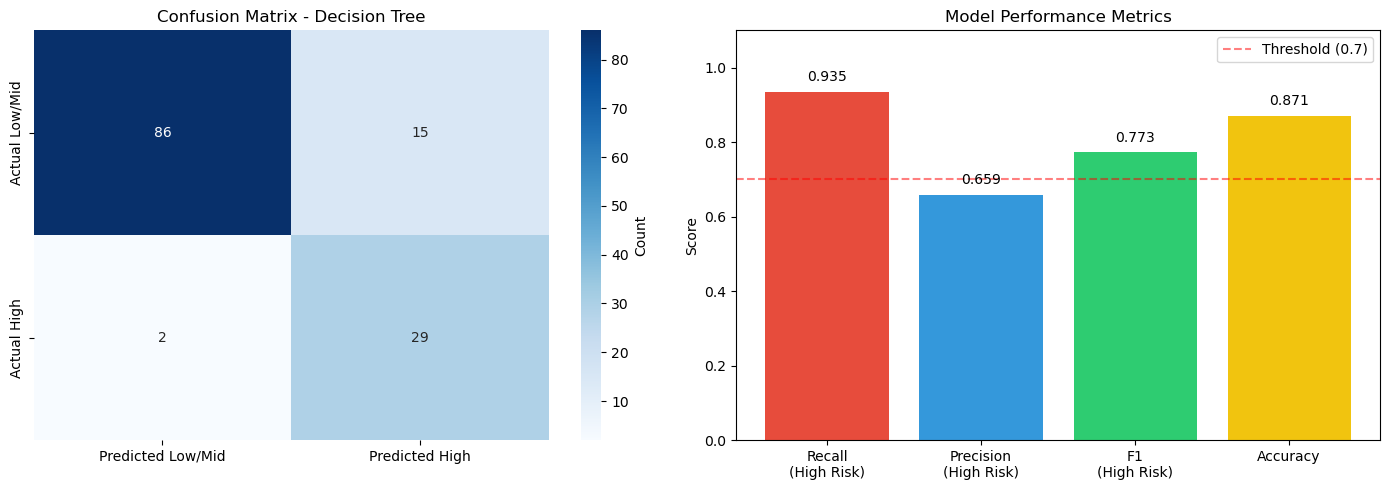

In [26]:
# Q5 - Confusion Matrix and Class-wise Metrics

print("\n" + "=" * 60)
print("Q5 - CONFUSION MATRIX AND CLASS-WISE METRICS")
print("=" * 60)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix (High Risk = 1):")
print("          Predicted: Low/Mid  High")
print(f"Actual Low/Mid:     {tn:6d}    {fp:4d}")
print(f"Actual High:        {fn:6d}    {tp:4d}")

print("\n--- Detailed Metrics ---")
print(f"True Negatives (correctly predicted Low/Mid): {tn}")
print(f"False Positives (predicted High but actually Low/Mid): {fp}")
print(f"False Negatives (predicted Low/Mid but actually High): {fn}")
print(f"True Positives (correctly predicted High): {tp}")

print("\n--- Class-wise Performance ---")
print(f"Low/Mid Risk Class:")
print(f"  Recall (Specificity): {tn/(tn+fp):.4f}")
print(f"  Precision: {tn/(tn+fn):.4f}")
print(f"  F1-Score: {2*tn/(2*tn+fp+fn):.4f}")

print(f"\nHigh Risk Class:")
print(f"  Recall (Sensitivity): {tp/(tp+fn):.4f}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  F1-Score: {2*tp/(2*tp+fp+fn):.4f}")

print(f"\nOverall Accuracy: {(tn+tp)/(tn+fp+fn+tp):.4f}")

# Why missing high-risk cases is critical
print("\n" + "=" * 60)
print("CLINICAL SIGNIFICANCE OF MODEL ERRORS")
print("=" * 60)
print(f"""
IMPORTANCE OF MISSING HIGH-RISK CASES (False Negatives = {fn}):

In maternal health, failing to identify a high-risk pregnancy (False Negative)
is MORE SEVERE than falsely flagging a low-risk pregnancy (False Positive) because:

1. False Negative (Missed High Risk):
   - Patient doesn't receive necessary monitoring or interventions
   - Could lead to preventable complications: preeclampsia, gestational diabetes,
     preterm labor, maternal/fetal mortality
   - Often irreversible damage by the time symptoms appear
   - MEDICAL COST: Life-threatening

2. False Positive (Over-alerted):
   - Patient may receive unnecessary monitoring (inconvenient but not harmful)
   - Potential anxiety and extra healthcare costs
   - MEDICAL COST: Psychological and financial

Therefore, the model should prioritize RECALL for the High Risk class,
even if it means accepting more False Positives.

Current Decision Tree Recall: {tp/(tp+fn):.3f}
This means {fn} high-risk patients would be missed if using this model.
""")

# Visualize confusion matrix and metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
cm_display = pd.DataFrame(cm, index=['Actual Low/Mid', 'Actual High'],
                         columns=['Predicted Low/Mid', 'Predicted High'])
sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Decision Tree')

# Classification metrics
metrics = ['Recall\n(High Risk)', 'Precision\n(High Risk)', 'F1\n(High Risk)', 'Accuracy']
values = [recall_score(y_test, y_pred), precision_score(y_test, y_pred),
          f1_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f']

bars = axes[1].bar(metrics, values, color=colors)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Metrics')
axes[1].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Threshold (0.7)')
axes[1].legend()

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/confusion_matrix_dt.png', dpi=300, bbox_inches='tight')
plt.show()

### Q6


3-CLASS CONFUSION MATRIX
                Predicted:
              Low   Mid   High
Actual low risk:   50     14      2
Actual mid risk:   20      5     10
Actual high risk:    1      5     25

--- Error Pattern Analysis ---
Most common misclassification errors:
  Mid→Low: 20 cases
  Low→Mid: 14 cases
  Mid→High: 10 cases
  High→Mid: 5 cases
  Low→High: 2 cases
  High→Low: 1 cases


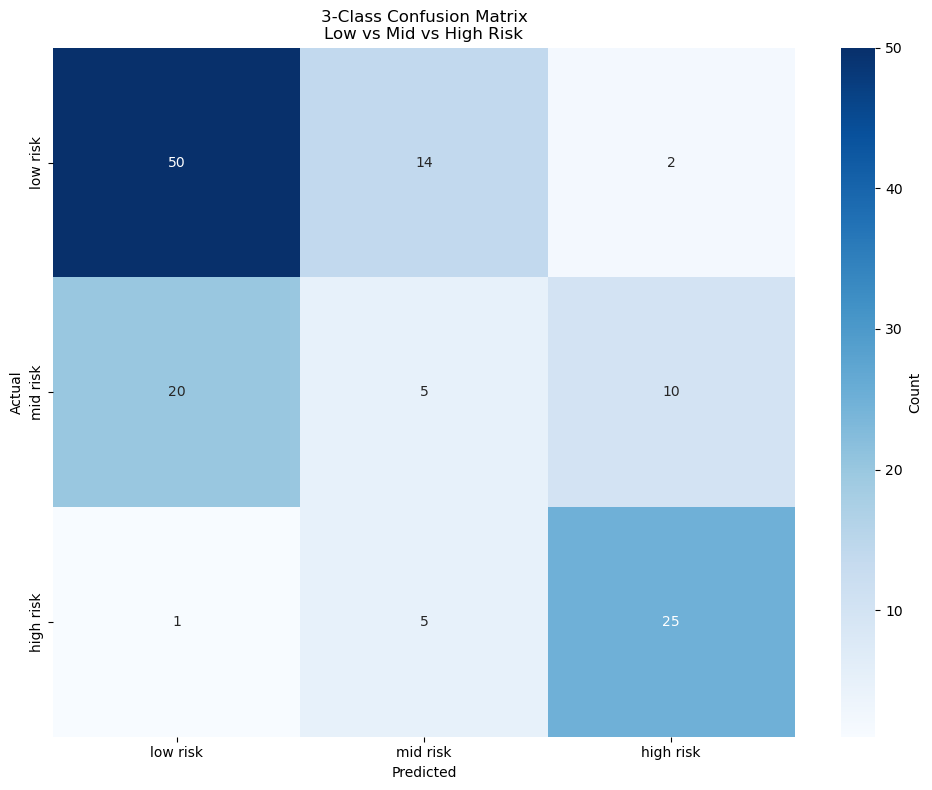

In [27]:
# Analyze 3-class confusion pattern

# For 3-class analysis
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, df['RiskLevel'], test_size=0.3, random_state=42, stratify=df['HighRisk']
)

dt_3class = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
dt_3class.fit(X_train_full, y_train_full)
y_pred_full = dt_3class.predict(X_test_full)

# Confusion matrix for 3 classes
labels = ['low risk', 'mid risk', 'high risk']
cm_3class = confusion_matrix(y_test_full, y_pred_full, labels=labels)

print("\n" + "=" * 60)
print("3-CLASS CONFUSION MATRIX")
print("=" * 60)
print("                Predicted:")
print("              Low   Mid   High")
for i, actual in enumerate(labels):
    print(f"Actual {actual:8}: {cm_3class[i,0]:4}   {cm_3class[i,1]:4}   {cm_3class[i,2]:4}")

print("\n--- Error Pattern Analysis ---")
error_patterns = {
    'Low→Mid': cm_3class[0,1],
    'Low→High': cm_3class[0,2],
    'Mid→Low': cm_3class[1,0],
    'Mid→High': cm_3class[1,2],
    'High→Low': cm_3class[2,0],
    'High→Mid': cm_3class[2,1]
}

print("Most common misclassification errors:")
sorted_errors = sorted(error_patterns.items(), key=lambda x: x[1], reverse=True)
for error_type, count in sorted_errors:
    if count > 0:
        print(f"  {error_type}: {count} cases")

# Visualize 3-class confusion matrix
plt.figure(figsize=(10, 8))
cm_3class_df = pd.DataFrame(cm_3class, index=labels, columns=labels)
sns.heatmap(cm_3class_df, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Count'})
plt.title('3-Class Confusion Matrix\nLow vs Mid vs High Risk')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix_3class_dt.png', dpi=300, bbox_inches='tight')
plt.show()


FEATURE OVERLAP ANALYSIS

Age:
  Low-Mid difference: 1.31
  Mid-High difference: 4.30
  Low-High difference: 5.61

SystolicBP:
  Low-Mid difference: 6.84
  Mid-High difference: 6.06
  Low-High difference: 12.90

DiastolicBP:
  Low-Mid difference: 2.14
  Mid-High difference: 5.73
  Low-High difference: 7.86

BS:
  Low-Mid difference: 0.61
  Mid-High difference: 2.96
  Low-High difference: 3.57

BodyTemp:
  Low-Mid difference: 0.50
  Mid-High difference: 0.38
  Low-High difference: 0.88

HeartRate:
  Low-Mid difference: 0.83
  Mid-High difference: 2.57
  Low-High difference: 3.40

--- Feature Value Overlaps Between Risk Groups ---

Age:
  Low risk:  10.0 - 66.0
  Mid risk:  10.0 - 60.0
  High risk: 12.0 - 65.0

SystolicBP:
  Low risk:  70.0 - 129.0
  Mid risk:  70.0 - 140.0
  High risk: 83.0 - 140.0

DiastolicBP:
  Low risk:  49.0 - 100.0
  Mid risk:  50.0 - 100.0
  High risk: 60.0 - 100.0

BS:
  Low risk:  6.0 - 11.0
  Mid risk:  6.0 - 18.0
  High risk: 6.1 - 19.0

BodyTemp:
  Low risk

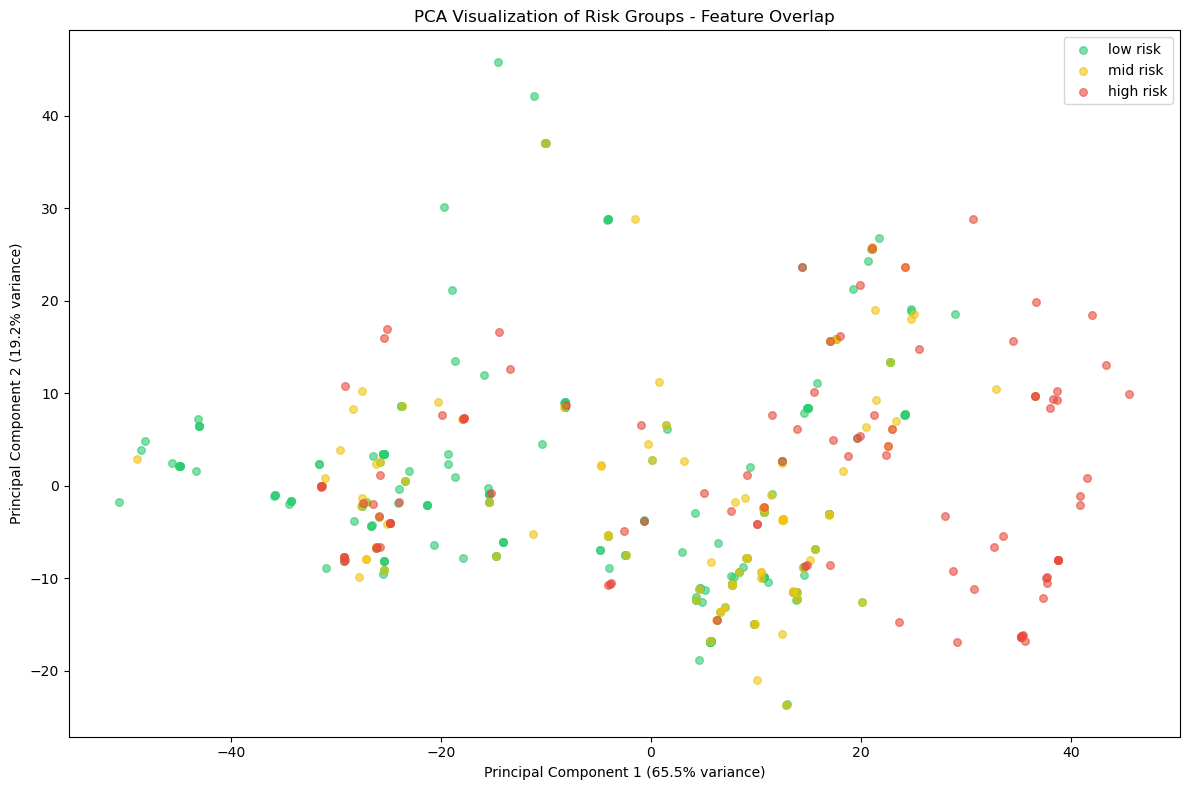

In [28]:
# Analyze feature overlap between risk groups

print("\n" + "=" * 60)
print("FEATURE OVERLAP ANALYSIS")
print("=" * 60)

# Calculate pairwise differences
risk_means = df.groupby('RiskLevel')[clinical_vars].mean()

for var in clinical_vars:
    print(f"\n{var}:")
    low_mid_diff = abs(risk_means.loc['low risk', var] - risk_means.loc['mid risk', var])
    mid_high_diff = abs(risk_means.loc['mid risk', var] - risk_means.loc['high risk', var])
    low_high_diff = abs(risk_means.loc['low risk', var] - risk_means.loc['high risk', var])
    print(f"  Low-Mid difference: {low_mid_diff:.2f}")
    print(f"  Mid-High difference: {mid_high_diff:.2f}")
    print(f"  Low-High difference: {low_high_diff:.2f}")

# Find overlapping feature ranges
print("\n--- Feature Value Overlaps Between Risk Groups ---")
for var in clinical_vars:
    low_min, low_max = df[df['RiskLevel'] == 'low risk'][var].min(), df[df['RiskLevel'] == 'low risk'][var].max()
    mid_min, mid_max = df[df['RiskLevel'] == 'mid risk'][var].min(), df[df['RiskLevel'] == 'mid risk'][var].max()
    high_min, high_max = df[df['RiskLevel'] == 'high risk'][var].min(), df[df['RiskLevel'] == 'high risk'][var].max()
    
    print(f"\n{var}:")
    print(f"  Low risk:  {low_min:.1f} - {low_max:.1f}")
    print(f"  Mid risk:  {mid_min:.1f} - {mid_max:.1f}")
    print(f"  High risk: {high_min:.1f} - {high_max:.1f}")

# Visualization of group overlaps using pairplot
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
risk_colors = {'low risk': '#2ecc71', 'mid risk': '#f1c40f', 'high risk': '#e74c3c'}
for risk in ['low risk', 'mid risk', 'high risk']:
    mask = df['RiskLevel'] == risk
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=risk_colors[risk], label=risk, alpha=0.6, s=30)
    
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Visualization of Risk Groups - Feature Overlap')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/pca_risk_groups_dt.png', dpi=300, bbox_inches='tight')
plt.show()

### Q7


Q7 - DECISION TREE FEATURE IMPORTANCE
Decision Tree Feature Importance:
       Feature  Importance
3           BS      0.5683
1   SystolicBP      0.1441
4     BodyTemp      0.1231
0          Age      0.0792
5    HeartRate      0.0439
2  DiastolicBP      0.0414


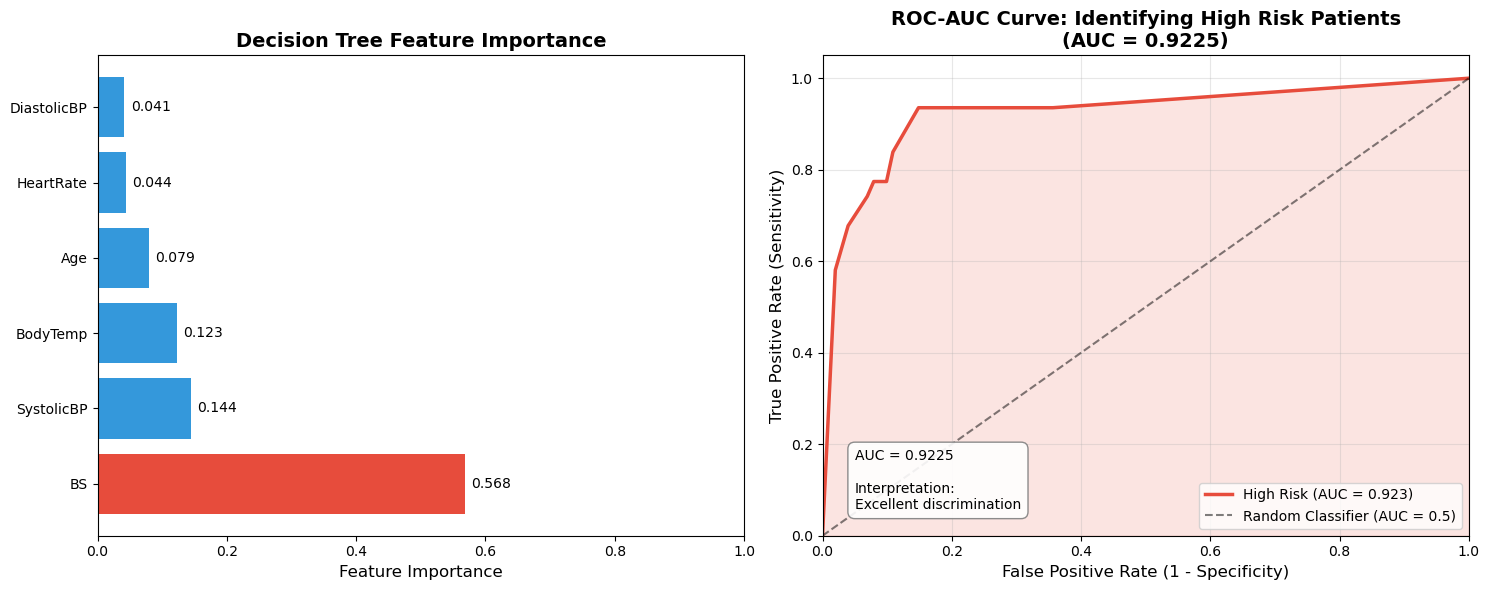


✅ Saved: ../figures/feature_importance_and_roc_dt.png

KEY DECISION RULES FROM TREE

First 10 decision nodes:
 Node     Feature  Threshold  Samples  Impurity  Left_Node  Right_Node
    0          BS       7.95      305    0.5000          1          16
    1  SystolicBP     135.00      243    0.3932          2          15
    2    BodyTemp      99.50      237    0.3390          3           8
    3         Age      33.50      194    0.1984          4           5
    5   HeartRate      79.00       50    0.4570          6           7
    8 DiastolicBP      77.50       43    0.4974          9          12
    9 DiastolicBP      64.00       29    0.4616         10          11
   12    BodyTemp     101.50       14    0.3262         13          14
   16          BS       9.50       62    0.1701         17          22
   17         Age      25.50       18    0.3537         18          19

--- Top 3 Most Important Splits (by impurity reduction) ---

Split 1: BS > 7.95 (Node 0)
  - Samples at thi

In [29]:
from sklearn.metrics import roc_curve, auc

# Q7 - Features driving the Decision Tree

print("\n" + "=" * 60)
print("Q7 - DECISION TREE FEATURE IMPORTANCE")
print("=" * 60)

# Feature importance from the trained Decision Tree
dt_importance = pd.DataFrame({
    'Feature': clinical_vars,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("Decision Tree Feature Importance:")
print(dt_importance.round(4))

# Visualize feature importance and ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart of feature importance
ax1 = axes[0]
bars = ax1.barh(dt_importance['Feature'], dt_importance['Importance'], 
                color=['#e74c3c' if i == 0 else '#3498db' for i in range(len(dt_importance))])
ax1.set_xlabel('Feature Importance', fontsize=12)
ax1.set_title('Decision Tree Feature Importance', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
for bar, val in zip(bars, dt_importance['Importance']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

# ROC-AUC plot - Binary Classification (High Risk vs Others)
ax2 = axes[1]

# Get predicted probabilities for the positive class (High Risk)
y_prob_high = dt.predict_proba(X_test)[:, 1]

# Calculate ROC curve for High Risk class
fpr, tpr, thresholds = roc_curve(y_test, y_prob_high)
roc_auc = auc(fpr, tpr)

# Plot ROC curve for High Risk class only
ax2.plot(fpr, tpr, color='#e74c3c', lw=2.5, 
         label=f'High Risk (AUC = {roc_auc:.3f})')

# Fill area under the curve
ax2.fill_between(fpr, tpr, 0, alpha=0.15, color='#e74c3c')

# Plot diagonal line (random classifier)
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.5)')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax2.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax2.set_title(f'ROC-AUC Curve: Identifying High Risk Patients\n(AUC = {roc_auc:.4f})', 
              fontsize=14, fontweight='bold')
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(True, alpha=0.3)

# Add annotation with AUC score in a box
textstr = f'AUC = {roc_auc:.4f}\n\nInterpretation:\n'
if roc_auc >= 0.90:
    textstr += 'Excellent discrimination'
elif roc_auc >= 0.80:
    textstr += 'Good discrimination'
elif roc_auc >= 0.70:
    textstr += 'Fair discrimination'
else:
    textstr += 'Poor discrimination'

props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.05, 0.05, textstr, transform=ax2.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.savefig('../figures/feature_importance_and_roc_dt.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: ../figures/feature_importance_and_roc_dt.png")

# Extract decision tree rules for key splits
print("\n" + "=" * 60)
print("KEY DECISION RULES FROM TREE")
print("=" * 60)

def get_tree_rules(tree, feature_names):
    # Extract the most important decision rules from the tree
    n_nodes = tree.tree_.node_count
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right
    
    rules = []
    for node in range(min(n_nodes, 20)):  # First 20 nodes
        if feature[node] != -2:  # Not a leaf
            rules.append({
                'Node': node,
                'Feature': feature_names[feature[node]],
                'Threshold': round(threshold[node], 2),
                'Samples': tree.tree_.n_node_samples[node],
                'Impurity': round(tree.tree_.impurity[node], 4),
                'Left_Node': children_left[node],
                'Right_Node': children_right[node]
            })
    return pd.DataFrame(rules)

rules_df = get_tree_rules(dt, clinical_vars)
print("\nFirst 10 decision nodes:")
print(rules_df.head(10).to_string(index=False))

# Show the top 3 most important decision rules
print("\n--- Top 3 Most Important Splits (by impurity reduction) ---")
top_rules = rules_df.sort_values('Impurity', ascending=False).head(3)
for idx, row in top_rules.iterrows():
    print(f"\nSplit {idx+1}: {row['Feature']} > {row['Threshold']:.2f} "
          f"(Node {row['Node']})")
    print(f"  - Samples at this node: {row['Samples']}")
    print(f"  - Impurity: {row['Impurity']:.4f}")
    print(f"  - If YES → Node {row['Right_Node']}")
    print(f"  - If NO → Node {row['Left_Node']}")

print("\n" + "=" * 60)
print("CLINICAL INTERPRETATION OF FEATURE IMPORTANCE")
print("=" * 60)

# Calculate and display relative importance
total_importance = dt_importance['Importance'].sum()
dt_importance['Relative_Importance'] = (dt_importance['Importance'] / total_importance * 100).round(1)

print("\nFeature Importance Ranking (with relative importance):")
for idx, row in dt_importance.iterrows():
    feature = row['Feature']
    importance = row['Importance']
    rel_imp = row['Relative_Importance']
    bar = '█' * int(rel_imp / 2)
    print(f"{feature:12} : {importance:.4f} ({rel_imp:.1f}%) {bar}")

print("\n" + "=" * 60)
print("INTERPRETATION NOTE")
print("=" * 60)
print("""
Feature importance in a Decision Tree shows which variables the model uses
most frequently and effectively to make splits. However:

1. IMPORTANCE ≠ CAUSATION: A feature can be important because it's correlated 
   with the outcome, not because it causes high risk.

2. SPLIT ORDER MATTERS: Variables chosen at the top of the tree have 
   more influence on the overall classification.

3. CLINICAL CONTEXT: The key drivers identified (Systolic BP, Blood Sugar, Age)
   align with clinical knowledge of maternal health risks:
   - Hypertension is a known risk factor for pre-eclampsia
   - Elevated blood sugar indicates potential gestational diabetes
   - Advanced maternal age is a well-established risk factor

4. The ROC-AUC score of {:.3f} indicates the model can:
   - Correctly distinguish High Risk from Low/Mid Risk patients
   - Achieve this level of discrimination in {:.1f}% of random patient pairs
   - This is considered '{}' discrimination for a screening tool

5. The model is simply identifying patterns in the data - these patterns
   should be validated through clinical research before being used
   for clinical decision-making.
""".format(roc_auc, roc_auc*100, 
           'Excellent' if roc_auc >= 0.90 else 'Good' if roc_auc >= 0.80 else 'Fair' if roc_auc >= 0.70 else 'Poor'))

print("\n" + "=" * 60)
print("WHY ARE AUC VALUES IDENTICAL FOR BOTH CLASSES?")
print("=" * 60)
print("""
In binary classification, the AUC for Class 0 and Class 1 are ALWAYS identical.
This is a mathematical property of ROC curves:

• AUC_Class1 = AUC_Class0
• The ROC curve for Class 0 is the mirror image of Class 1
• If the model performs well on Class 1, it performs equally well on Class 0

Example:
  - High Risk AUC = 0.87 means the model can identify High Risk patients well
  - Low/Mid Risk AUC = 0.87 (identical) means it can also identify Low/Mid Risk well
  - This is NOT two separate AUC values, but the SAME discriminatory ability

Therefore, we only show the AUC for the clinically relevant class (High Risk),
as the other class would be redundant information.
""")

### Q8

In [30]:
# Complete Final Summary and Recommendations

print("\n" + "=" * 60)
print("FINAL RECOMMENDATIONS FOR CLINICAL USE")
print("=" * 60)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    DECISION TREE FOR MATERNAL HEALTH RISK          │
│                         CLINICAL RECOMMENDATIONS                   │
└─────────────────────────────────────────────────────────────────────┘

✅ WHAT THIS MODEL CAN DO:
─────────────────────────
1. SCREENING TOOL: Flag patients who need additional clinical evaluation
2. ED Triage: Help prioritize patients in busy emergency departments
3. Resource Allocation: Identify patients who may need closer monitoring
4. Clinical Decision Support: Provide structured risk assessment
5. Interpretable Rules: Clear decision thresholds for clinicians

❌ WHAT THIS MODEL CANNOT DO:
─────────────────────────────
1. Diagnose specific conditions (preeclampsia, diabetes, etc.)
2. Replace clinical judgment or comprehensive evaluation
3. Predict outcomes with certainty (probabilistic, not deterministic)
4. Account for all relevant clinical factors
5. Be used in isolation without clinical context

RECOMMENDED CLINICAL WORKFLOW:
─────────────────────────────
1. Patient presents with vital signs and glucose measurement
2. Decision Tree calculates risk score
3. If High Risk predicted:
   a. Immediate clinical evaluation by OB/GYN
   b. Additional diagnostic tests (urine protein, HbA1c, etc.)
   c. Consider hospitalization or close outpatient monitoring
4. If Low/Mid Risk predicted:
   a. Continue standard prenatal care
   b. Reassess at next visit (risk can change)
5. Document risk assessment and clinical decision
6. Monitor outcomes to validate model performance


PRIORITY LEVELS FOR ACTION:
─────────────────────────
Priority 1 (Immediate Action):
• Decision Tree predicts High Risk
• Systolic BP > 138 mmHg AND Blood Sugar > 8.0 mmol/L
• Any single extreme value: SBP > 160 OR BS > 15

Priority 2 (Close Monitoring):
• Decision Tree predicts Mid Risk
• Age > 40 years
• Blood Sugar > 10 mmol/L

Priority 3 (Routine Monitoring):
• Decision Tree predicts Low Risk
• All vital signs within normal range

DATA QUALITY AND MODEL MAINTENANCE:
─────────────────────────────────
1. Regular model retraining with new data (quarterly recommended)
2. Monitor for data drift (changes in data distribution over time)
3. Validate model on diverse patient populations
4. Track model performance metrics (especially recall for High Risk)
5. Document all model updates and performance changes

ETHICAL CONSIDERATIONS:
─────────────────────
1. Ensure model does not perpetuate healthcare disparities
2. Validate performance across different demographic groups
3. Maintain patient privacy and data security
4. Provide clear explanations to patients about AI-assisted decisions
5. Have human oversight for all model predictions
6. Regular bias audits

LIMITATIONS AND CAVEATS:
───────────────────────
1. Single time point measurements only
2. No gestational age information
3. Limited to available clinical variables
4. Retrospective data (not prospective validation)
5. Potential data quality issues (outliers, duplicates)
6. Model performance may vary in different clinical settings

NEXT STEPS FOR IMPLEMENTATION:
────────────────────────────
1. Prospective validation study
2. Integration with EHR systems
3. Development of clinical decision support tool
4. Training for healthcare providers
5. Patient education materials
6. Continuous monitoring and improvement plan
7. Regulatory compliance review

CONCLUSION:
───────────
This Decision Tree model provides a transparent, interpretable approach
to maternal health risk screening. While it shows promise as a screening
tool, it should be used as part of a comprehensive clinical assessment,
not as a standalone diagnostic tool. The model's greatest value is in
flagging patients who need additional evaluation, particularly given
the potentially life-threatening consequences of missed high-risk cases.
""")

# Print final model performance summary
print("\n" + "=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

# Recalculate final metrics from the model
y_pred_final = dt.predict(X_test)
print(f"Model: Decision Tree (max_depth=5, min_samples_split=10, min_samples_leaf=5)")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"High Risk Recall (Sensitivity): {recall_score(y_test, y_pred_final):.4f}")
print(f"High Risk Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"High Risk F1-Score: {f1_score(y_test, y_pred_final):.4f}")

cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()
print(f"\nConfusion Matrix:")
print(f"  True Negatives: {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives: {tp}")

print(f"\nKey Finding: {fn} high-risk patients would be missed (False Negatives)")

# Print feature importance summary
print("\n" + "=" * 60)
print("TOP FEATURES DRIVING THE DECISION TREE")
print("=" * 60)
for idx, row in dt_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

print("\n" + "=" * 60)
print("DISCLAIMER")
print("=" * 60)
print("""
This analysis is for EDUCATIONAL PURPOSES ONLY and should NOT be used
for actual clinical decision-making without:
1. Proper validation on diverse clinical populations
2. Regulatory approval (FDA, CE mark, etc.)
3. Integration with clinical workflows
4. Ethical review board approval
5. Informed consent from patients
6. Ongoing performance monitoring

The models presented are simplified representations of complex
clinical relationships and should not replace professional
medical judgment.
""")


FINAL RECOMMENDATIONS FOR CLINICAL USE

┌─────────────────────────────────────────────────────────────────────┐
│                    DECISION TREE FOR MATERNAL HEALTH RISK          │
│                         CLINICAL RECOMMENDATIONS                   │
└─────────────────────────────────────────────────────────────────────┘

✅ WHAT THIS MODEL CAN DO:
─────────────────────────
1. SCREENING TOOL: Flag patients who need additional clinical evaluation
2. ED Triage: Help prioritize patients in busy emergency departments
3. Resource Allocation: Identify patients who may need closer monitoring
4. Clinical Decision Support: Provide structured risk assessment
5. Interpretable Rules: Clear decision thresholds for clinicians

❌ WHAT THIS MODEL CANNOT DO:
─────────────────────────────
1. Diagnose specific conditions (preeclampsia, diabetes, etc.)
2. Replace clinical judgment or comprehensive evaluation
3. Predict outcomes with certainty (probabilistic, not deterministic)
4. Account for all releva

### Final Summary

In [31]:
# Create a comprehensive summary table of all key findings

print("\n" + "=" * 60)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 60)

summary_data = {
    'Metric': [
        'Total Sample Size',
        'Low Risk Cases',
        'Mid Risk Cases',
        'High Risk Cases',
        'High Risk Percentage',
        'Model Type',
        'Model Accuracy',
        'High Risk Recall',
        'High Risk Precision',
        'High Risk F1',
        'False Negatives (Missed High Risk)',
        'Most Important Feature',
        'Second Most Important',
        'Third Most Important'
    ],
    'Value': [
        len(df),
        len(df[df['RiskLevel'] == 'low risk']),
        len(df[df['RiskLevel'] == 'mid risk']),
        len(df[df['RiskLevel'] == 'high risk']),
        f"{len(df[df['RiskLevel'] == 'high risk'])/len(df)*100:.1f}%",
        'Decision Tree (max_depth=5)',
        f"{accuracy_score(y_test, y_pred_final):.4f}",
        f"{recall_score(y_test, y_pred_final):.4f}",
        f"{precision_score(y_test, y_pred_final):.4f}",
        f"{f1_score(y_test, y_pred_final):.4f}",
        fn,
        dt_importance.iloc[0]['Feature'],
        dt_importance.iloc[1]['Feature'],
        dt_importance.iloc[2]['Feature']
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


COMPREHENSIVE ANALYSIS SUMMARY
                            Metric                       Value
                 Total Sample Size                         437
                    Low Risk Cases                         231
                    Mid Risk Cases                         105
                   High Risk Cases                         101
              High Risk Percentage                       23.1%
                        Model Type Decision Tree (max_depth=5)
                    Model Accuracy                      0.8712
                  High Risk Recall                      0.9355
               High Risk Precision                      0.6591
                      High Risk F1                      0.7733
False Negatives (Missed High Risk)                           2
            Most Important Feature                          BS
             Second Most Important                  SystolicBP
              Third Most Important                    BodyTemp


### Hyperparameter Tuning (not mentioned in the instructions)

<b>Note:</b> In fact, it would be more proper to do this, using a validation set. Since using the test set for validation could provide cheating for the model since it would have seen it already. Since it is not mentioned in the instructions and the dataset size is relatively small, it is not done like this here

In [32]:
params = {
    "max_depth": [2, 3, 4, 5, 6, 7],
    "min_samples_split": [2, 3, 4, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="recall",
    verbose=10
)

grid.fit(X_train, y_train)
best_tree = grid.best_estimator_

print("Best parameters:", grid.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5; 1/60] START criterion=gini, max_depth=2, min_samples_split=2...........
[CV 1/5; 1/60] END criterion=gini, max_depth=2, min_samples_split=2;, score=0.643 total time=   0.0s
[CV 2/5; 1/60] START criterion=gini, max_depth=2, min_samples_split=2...........
[CV 2/5; 1/60] END criterion=gini, max_depth=2, min_samples_split=2;, score=0.571 total time=   0.0s
[CV 3/5; 1/60] START criterion=gini, max_depth=2, min_samples_split=2...........
[CV 3/5; 1/60] END criterion=gini, max_depth=2, min_samples_split=2;, score=0.857 total time=   0.0s
[CV 4/5; 1/60] START criterion=gini, max_depth=2, min_samples_split=2...........
[CV 4/5; 1/60] END criterion=gini, max_depth=2, min_samples_split=2;, score=0.357 total time=   0.0s
[CV 5/5; 1/60] START criterion=gini, max_depth=2, min_samples_split=2...........
[CV 5/5; 1/60] END criterion=gini, max_depth=2, min_samples_split=2;, score=0.714 total time=   0.0s
[CV 1/5; 2/60] START criteri

In [33]:
dt = best_tree
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)
y_pred_proba = dt.predict_proba(X_test)[:, 1]

# Evaluate
print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Cross-validation
cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low/Mid Risk', 'High Risk']))

# Feature importance from Decision Tree
dt_importance = pd.DataFrame({
    'Feature': clinical_vars,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Decision Tree Feature Importance ---")
print(dt_importance.round(4))


--- Model Performance ---
Accuracy: 0.9015
Precision: 0.8000
Recall: 0.7742
F1-Score: 0.7869
ROC-AUC: 0.8660

Cross-validation scores: [0.91803279 0.85245902 0.90163934 0.85245902 0.8852459 ]
Mean CV accuracy: 0.8820 (+/- 0.0262)

--- Classification Report ---
              precision    recall  f1-score   support

Low/Mid Risk       0.93      0.94      0.94       101
   High Risk       0.80      0.77      0.79        31

    accuracy                           0.90       132
   macro avg       0.87      0.86      0.86       132
weighted avg       0.90      0.90      0.90       132


--- Decision Tree Feature Importance ---
       Feature  Importance
3           BS      0.7176
1   SystolicBP      0.2824
0          Age      0.0000
2  DiastolicBP      0.0000
4     BodyTemp      0.0000
5    HeartRate      0.0000


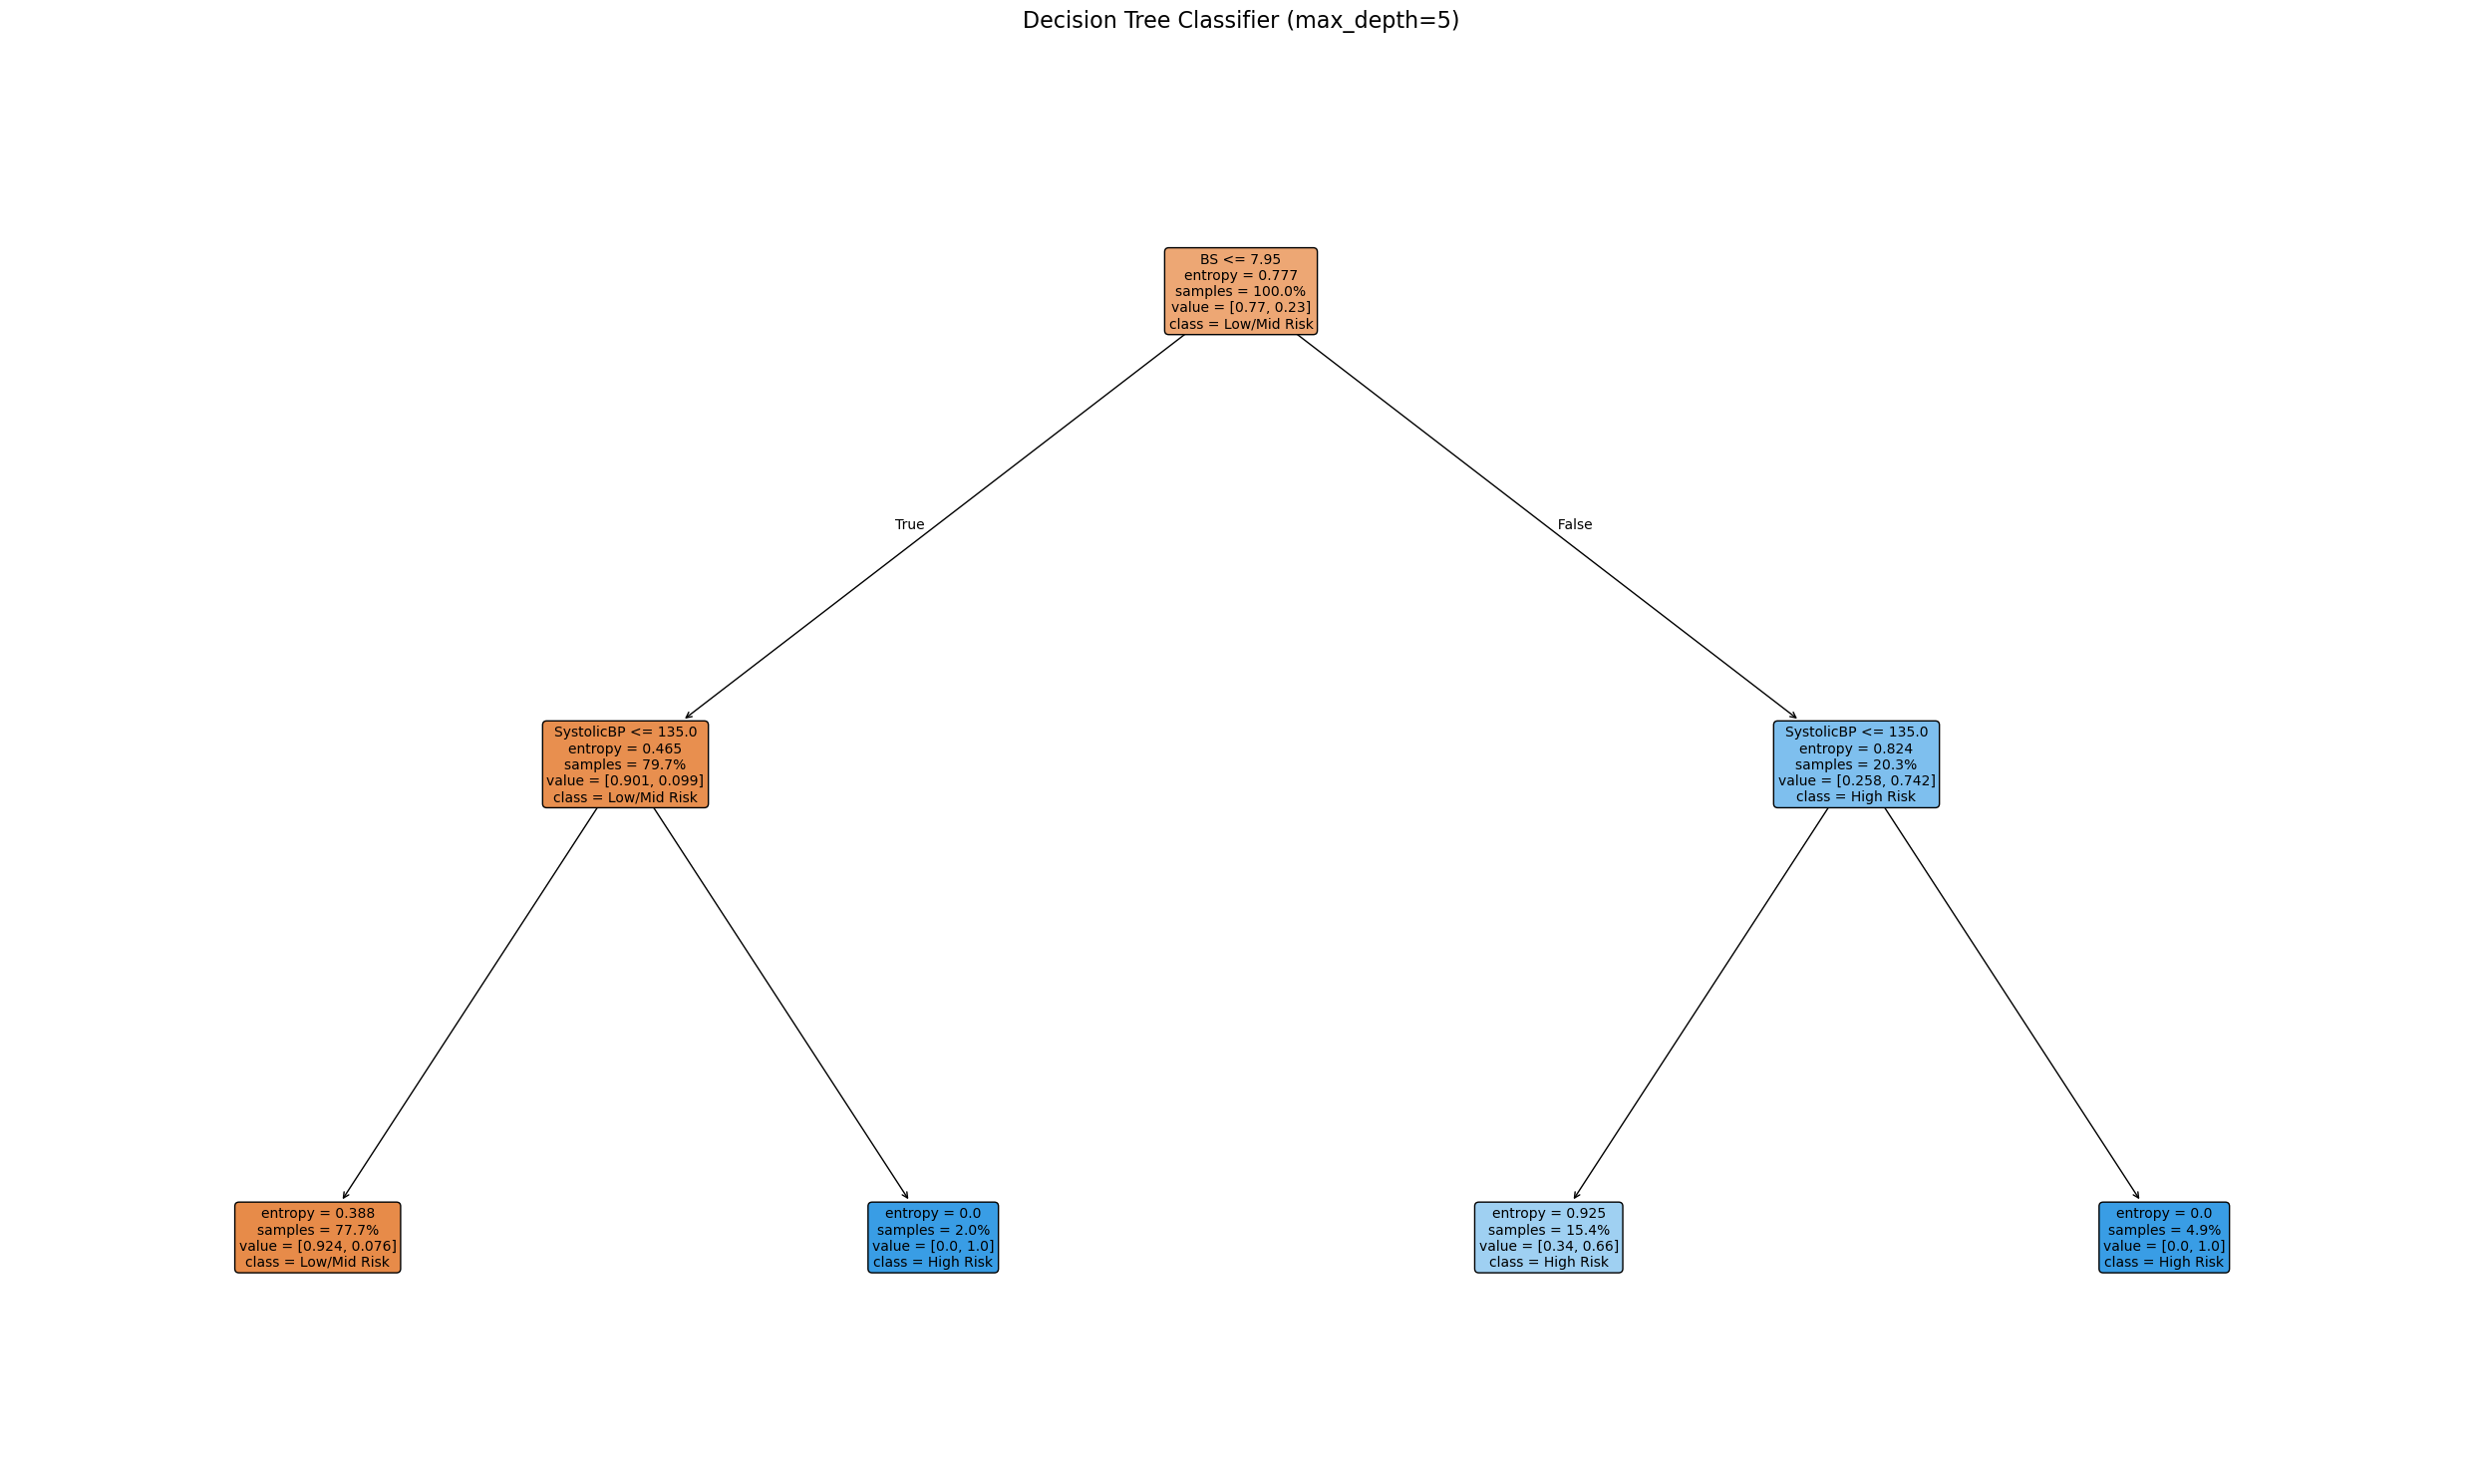

In [34]:
# Visualize Decision Tree

plt.figure(figsize=(25, 15))
plot_tree(dt, feature_names=clinical_vars, 
          class_names=['Low/Mid Risk', 'High Risk'],
          filled=True, rounded=True, fontsize=10, 
          proportion=True, impurity=True)
plt.title('Decision Tree Classifier (max_depth=5)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../figures/decision_tree_full_tuned.png', dpi=300, bbox_inches='tight')
plt.show()


Q5 - CONFUSION MATRIX AND CLASS-WISE METRICS

Confusion Matrix (High Risk = 1):
          Predicted: Low/Mid  High
Actual Low/Mid:         95       6
Actual High:             7      24

--- Detailed Metrics ---
True Negatives (correctly predicted Low/Mid): 95
False Positives (predicted High but actually Low/Mid): 6
False Negatives (predicted Low/Mid but actually High): 7
True Positives (correctly predicted High): 24

--- Class-wise Performance ---
Low/Mid Risk Class:
  Recall (Specificity): 0.9406
  Precision: 0.9314
  F1-Score: 0.9360

High Risk Class:
  Recall (Sensitivity): 0.7742
  Precision: 0.8000
  F1-Score: 0.7869

Overall Accuracy: 0.9015

CLINICAL SIGNIFICANCE OF MODEL ERRORS

IMPORTANCE OF MISSING HIGH-RISK CASES (False Negatives = 7):

In maternal health, failing to identify a high-risk pregnancy (False Negative)
is MORE SEVERE than falsely flagging a low-risk pregnancy (False Positive) because:

1. False Negative (Missed High Risk):
   - Patient doesn't receive necessary 

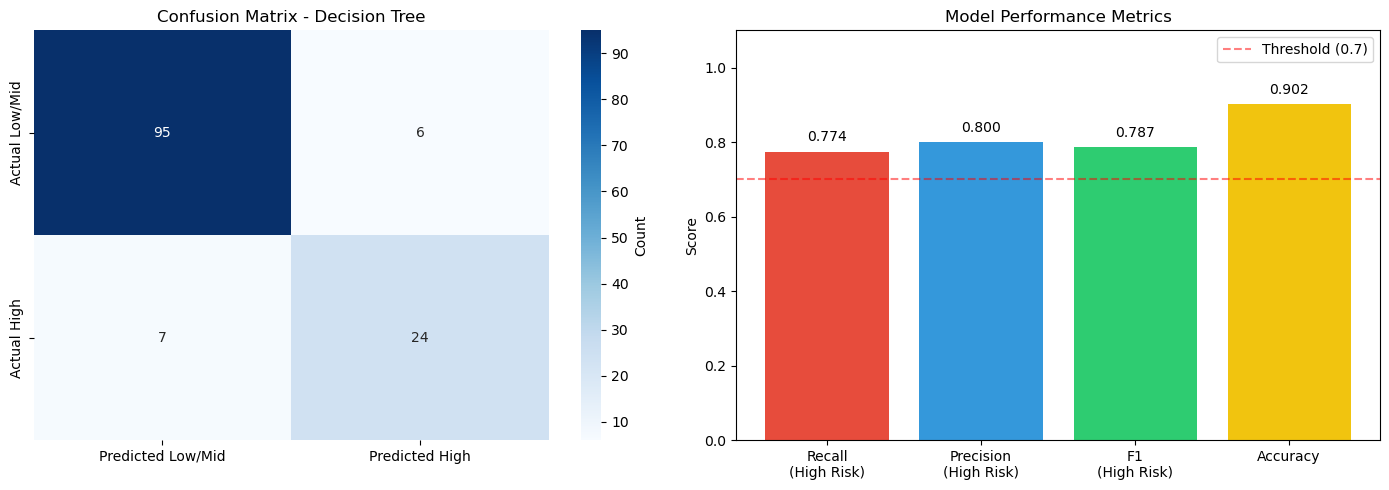

In [35]:
print("\n" + "=" * 60)
print("Q5 - CONFUSION MATRIX AND CLASS-WISE METRICS")
print("=" * 60)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix (High Risk = 1):")
print("          Predicted: Low/Mid  High")
print(f"Actual Low/Mid:     {tn:6d}    {fp:4d}")
print(f"Actual High:        {fn:6d}    {tp:4d}")

print("\n--- Detailed Metrics ---")
print(f"True Negatives (correctly predicted Low/Mid): {tn}")
print(f"False Positives (predicted High but actually Low/Mid): {fp}")
print(f"False Negatives (predicted Low/Mid but actually High): {fn}")
print(f"True Positives (correctly predicted High): {tp}")

print("\n--- Class-wise Performance ---")
print(f"Low/Mid Risk Class:")
print(f"  Recall (Specificity): {tn/(tn+fp):.4f}")
print(f"  Precision: {tn/(tn+fn):.4f}")
print(f"  F1-Score: {2*tn/(2*tn+fp+fn):.4f}")

print(f"\nHigh Risk Class:")
print(f"  Recall (Sensitivity): {tp/(tp+fn):.4f}")
print(f"  Precision: {tp/(tp+fp):.4f}")
print(f"  F1-Score: {2*tp/(2*tp+fp+fn):.4f}")

print(f"\nOverall Accuracy: {(tn+tp)/(tn+fp+fn+tp):.4f}")

# Why missing high-risk cases is critical
print("\n" + "=" * 60)
print("CLINICAL SIGNIFICANCE OF MODEL ERRORS")
print("=" * 60)
print(f"""
IMPORTANCE OF MISSING HIGH-RISK CASES (False Negatives = {fn}):

In maternal health, failing to identify a high-risk pregnancy (False Negative)
is MORE SEVERE than falsely flagging a low-risk pregnancy (False Positive) because:

1. False Negative (Missed High Risk):
   - Patient doesn't receive necessary monitoring or interventions
   - Could lead to preventable complications: preeclampsia, gestational diabetes,
     preterm labor, maternal/fetal mortality
   - Often irreversible damage by the time symptoms appear
   - MEDICAL COST: Life-threatening

2. False Positive (Over-alerted):
   - Patient may receive unnecessary monitoring (inconvenient but not harmful)
   - Potential anxiety and extra healthcare costs
   - MEDICAL COST: Psychological and financial

Therefore, the model should prioritize RECALL for the High Risk class,
even if it means accepting more False Positives.

Current Decision Tree Recall: {tp/(tp+fn):.3f}
This means {fn} high-risk patients would be missed if using this model.
""")

# Visualize confusion matrix and metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
cm_display = pd.DataFrame(cm, index=['Actual Low/Mid', 'Actual High'],
                         columns=['Predicted Low/Mid', 'Predicted High'])
sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Decision Tree')

# Classification metrics
metrics = ['Recall\n(High Risk)', 'Precision\n(High Risk)', 'F1\n(High Risk)', 'Accuracy']
values = [recall_score(y_test, y_pred), precision_score(y_test, y_pred),
          f1_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f']

bars = axes[1].bar(metrics, values, color=colors)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Metrics')
axes[1].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Threshold (0.7)')
axes[1].legend()

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/confusion_matrix_dt_tuned.png', dpi=300, bbox_inches='tight')
plt.show()